In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import glob # <-- Importante
import os   # <-- Importante

In [2]:
# --- Cargar tus nuevos datos ---
# Reemplaza el path si es necesario
parquet_path = "ADST_Alexey/parquet/SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet"
df_new = pd.read_parquet(parquet_path)

# (Opcional) Si querés corregir el error de logE_REC = -inf que vimos
df_new.replace([np.inf, -np.inf], np.nan, inplace=True)
df_new.dropna(subset=['logE_REC'], inplace=True)

print(f"DataFrame 'df_new' cargado con {len(df_new)} filas (counters).")
print(df_new.head())

DataFrame 'df_new' cargado con 12251 filas (counters).
                                            event_id    logE_MC   theta_MC  \
0  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
1  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
2  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
3  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   
4  Library_Prague_Santos_Yushkov:Run_10000:Shower...  17.557002  10.497525   

       phi_MC primary   logE_REC  theta_REC     phi_REC  counterId  \
0  266.129022      He  17.424415   9.516247  269.459517     104022   
1  266.129022      He  17.424415   9.516247  269.459517     104023   
2  266.129022      He  17.424415   9.516247  269.459517     104041   
3  266.129022      He  17.424415   9.516247  269.459517     104021   
4  266.129022      He  17.424415   9.516247  269.459517     104009   

      nMuones  ...     y_plane  phi_plane      r_core  

In [3]:
print(df_new['sdId'].unique())

[4022 4023 4041 4021 4009 4010 4040 4216 4055 4215 4033 4032 4054 4056
 4075 4218 4214 4074 4003 4002 4001 4004 4011 4008 4019 4007 4018 4012
 4005 4025 4026 4045 4027 4047 4044 4013 4067 4031 4016 4015 4030 4029
 4052 4017 4024 4043 4014 4028 4049 4053 4212 4213 4073 4217 4048 4051
 4006 4034 4035 4058 4057 4046 4039 4020 4036 4038 4037 4061 4060 4042
 4059 4163 4064 4050 4096 4066 4097 4072 4188 4158 4151 4095 4116 4069
 4063 4130 4078 4081 4125 4071 4193 4106 4079 4206 4132 4085 4129 4070
 4076]


Generando gráfico 3D...


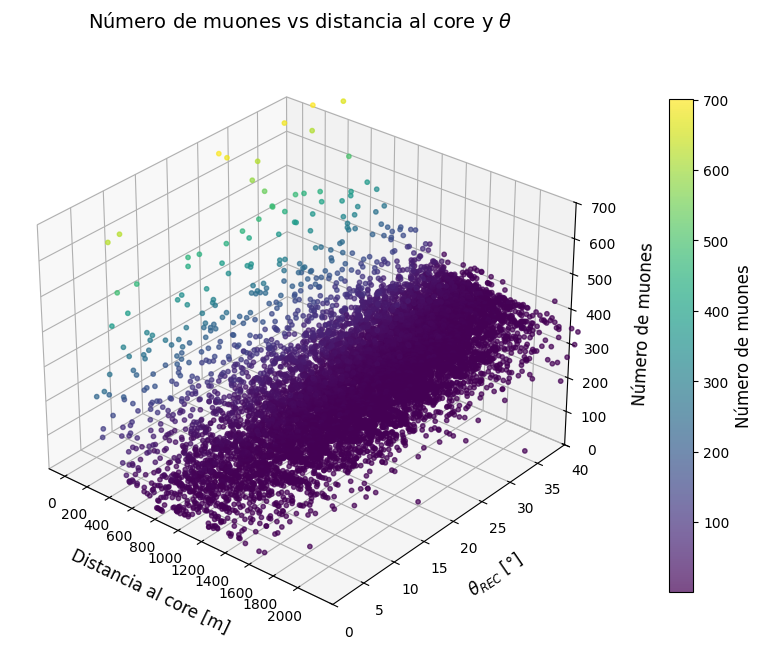

In [21]:
print("Generando gráfico 3D...")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# (Opcional) Filtremos un poco para que el plot sea más claro
# ej: sacamos counters sin muones o muy lejanos
df_plot = df_new[
    (df_new['nMuones'] > 0) &
    (df_new['r_core'] < 3000) # (Ajustá este límite si es necesario)
]

# Scatter
sc = ax.scatter(
    df_plot["r_core"],
    df_plot["theta_REC"],  # <-- Columna renombrada
    df_plot["nMuones"],
    c=df_plot["nMuones"], 
    cmap="viridis", 
    alpha=0.7,
    s=10 # Hago los puntos un poco más chicos
)

# Labels
ax.set_xlabel("Distancia al core [m]", fontsize=12, labelpad=10)
ax.set_ylabel(r"$\theta_{REC}$ [°]", fontsize=12, labelpad=10) # <-- Label actualizado
ax.set_zlabel("Número de muones", fontsize=12, labelpad=10)
plt.title(r"Número de muones vs distancia al core y $\theta$", fontsize=14, pad=20)

# Mejorar ticks (usando tu configuración)
ax.set_xticks(np.arange(0, 2000 + 1, 200))
ax.set_yticks(np.arange(0, 40 + 1, 5))
ax.set_ylim(0, 40) # (Tal vez quieras subir este límite si tus datos llegan a 60°)

# Zticks: Usar un log-scale o binear puede ser mejor
# pero siguiendo tu código original:
z_max = df_plot["nMuones"].max()
ax.set_zticks(np.arange(0, z_max + 1, 100)) # Ajustado a 100, ya que 50 era muy denso
ax.set_zlim(0, z_max) # Asegurarse de que el eje Z llegue al máximo

# Añadir barra de color
cbar = plt.colorbar(sc, pad=0.1, shrink=0.8)
cbar.set_label("Número de muones", fontsize=12)

# Rotar la vista
ax.view_init(elev=30, azim=310)

# Grid
ax.grid(True)

plt.show()

In [22]:
# --- 3. Crear DataFrame de EVENTOS ---
# Columnas que son únicas para cada evento (lluvia)
event_cols = [
    "run_number",
    "event_id",
    "logE_MC", "theta_MC", "phi_MC", 
    "primary", # 'primary' es de MC, así que también es por evento
    "logE_REC", "theta_REC", "phi_REC"
]

# Usamos drop_duplicates() para colapsar las 10-12 filas de cada evento en UNA sola.
df_events = df_new[event_cols].drop_duplicates()

print(f"DataFrame 'df_events' (lluvias) creado con {len(df_events)} filas únicas.")
df_events.head()

DataFrame 'df_events' (lluvias) creado con 1167 filas únicas.


,run_number,event_id,logE_MC,theta_MC,phi_MC,primary,logE_REC,theta_REC,phi_REC
0,10,Library_Prague_Santos_Yushkov:Run_10000:Shower...,17.557002,10.497525,266.129022,He,17.424415,9.516247,269.459517
7,10,Library_Prague_Santos_Yushkov:Run_10001:Shower...,17.514259,3.048157,315.899666,He,17.423894,3.140957,323.483553
15,10,Library_Prague_Santos_Yushkov:Run_10002:Shower...,17.509618,28.251578,331.123960,He,17.406819,27.135014,331.405738
24,10,Library_Prague_Santos_Yushkov:Run_10003:Shower...,17.896363,36.831416,117.406958,He,17.780786,36.541166,118.938084
37,10,Library_Prague_Santos_Yushkov:Run_10004:Shower...,17.755350,53.969303,169.547926,He,17.587915,53.550577,168.552741


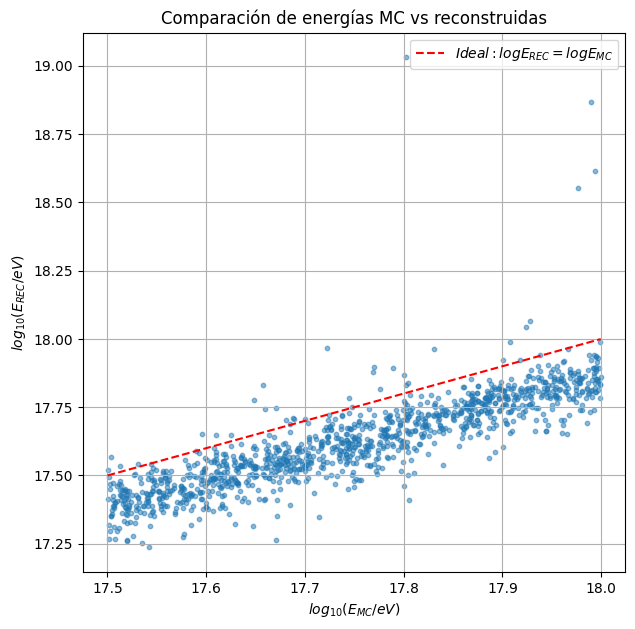

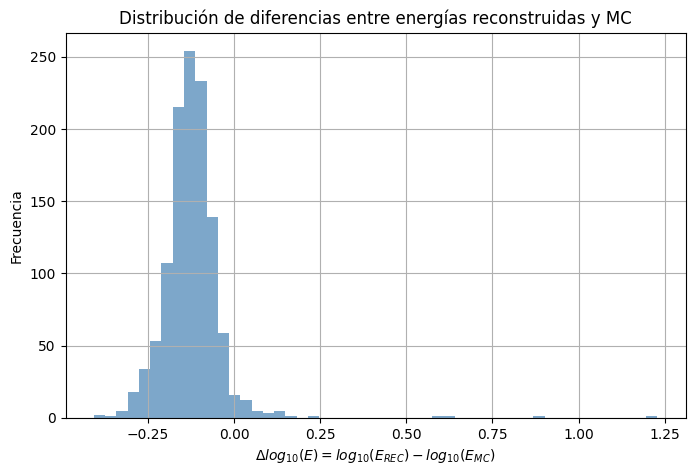

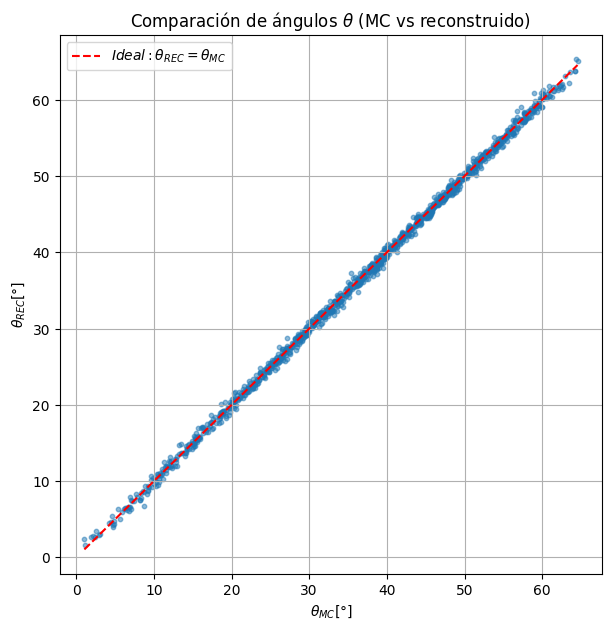

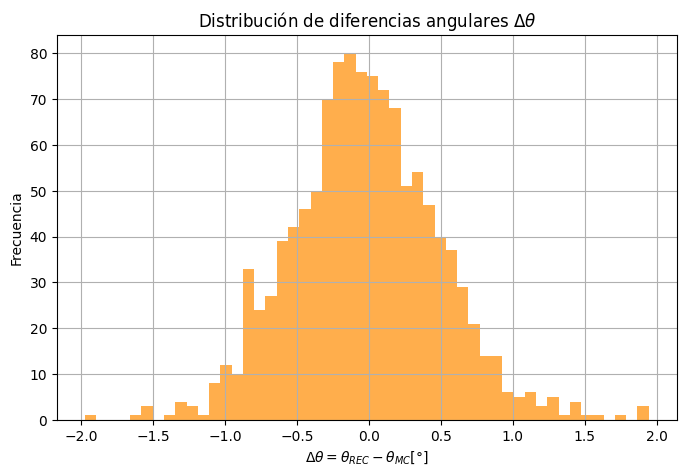

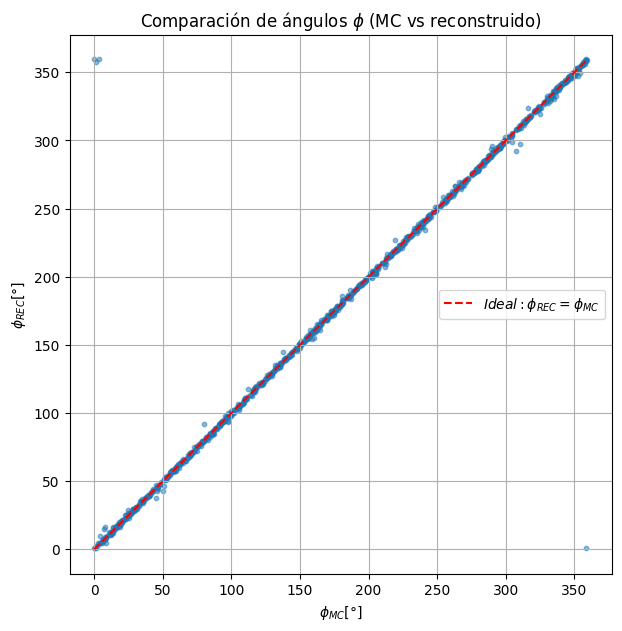

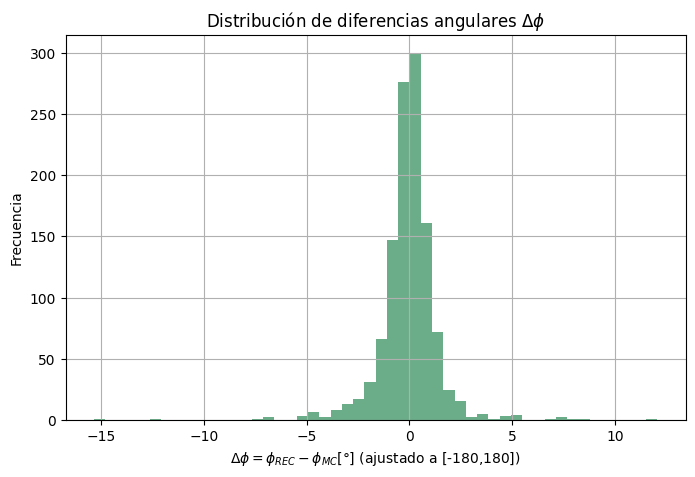

=== Energía (log10) ===
Promedio ΔlogE: -0.1248
Desviación estándar ΔlogE: 0.0896

=== Ángulo cenital θ ===
Promedio Δθ: -0.0251°
Desviación estándar Δθ: 0.5107°

=== Ángulo azimutal φ ===
Mediana Δφ: 0.0161°
MAD Δφ: 0.5663°


In [23]:
# --- 1. PLOTS DE RESOLUCIÓN (usando df_events) ---

# -------------------------------
# Comparar logE_MC vs logE_REC
# -------------------------------
plt.figure(figsize=(7, 7))
# ❗️ CAMBIO: df_all -> df_events
plt.scatter(df_events["logE_MC"], df_events["logE_REC"], s=10, alpha=0.5)
plt.plot([df_events["logE_MC"].min(), df_events["logE_MC"].max()],
         [df_events["logE_MC"].min(), df_events["logE_MC"].max()],
         'r--', label=r"$Ideal: logE_{REC} = logE_{MC}$")

plt.xlabel(r"$log_{10}(E_{MC} / eV)$")
plt.ylabel(r"$log_{10}(E_{REC} / eV)$")
plt.title("Comparación de energías MC vs reconstruidas")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Diferencia ΔlogE = logE_REC - logE_MC
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
deltaE = df_events["logE_REC"] - df_events["logE_MC"]
# (El resto de tu código de histograma es idéntico)
plt.figure(figsize=(8, 5))
plt.hist(deltaE.dropna(), bins=50, alpha=0.7, color='steelblue') # .dropna() por seguridad
plt.xlabel(r"$\Delta log_{10}(E) = log_{10}(E_{REC}) - log_{10}(E_{MC})$")
plt.ylabel("Frecuencia")
plt.title("Distribución de diferencias entre energías reconstruidas y MC")
plt.grid(True)
plt.show()

# -------------------------------
# THETA
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
plt.figure(figsize=(7,7))
plt.scatter(df_events["theta_MC"], df_events["theta_REC"], s=10, alpha=0.5)
plt.plot([df_events["theta_MC"].min(), df_events["theta_MC"].max()],
         [df_events["theta_MC"].min(), df_events["theta_MC"].max()],
         'r--', label=r"$Ideal: \theta_{REC} = \theta_{MC}$")
plt.xlabel(r"$\theta_{MC} [°]$")
plt.ylabel(r"$\theta_{REC} [°]$")
plt.title(r"Comparación de ángulos $\theta$ (MC vs reconstruido)")
plt.legend()
plt.grid(True)
plt.show()

# ❗️ CAMBIO: df_all -> df_events
delta_theta = df_events["theta_REC"] - df_events["theta_MC"]

plt.figure(figsize=(8,5))
plt.hist(delta_theta.dropna(), bins=50, alpha=0.7, color='darkorange') # .dropna()
plt.xlabel(r"$\Delta \theta = \theta_{REC} - \theta_{MC} [°]$")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de diferencias angulares $\Delta \theta$")
plt.grid(True)
plt.show()

# -------------------------------
# PHI
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
plt.figure(figsize=(7,7))
plt.scatter(df_events["phi_MC"], df_events["phi_REC"], s=10, alpha=0.5)
plt.plot([df_events["phi_MC"].min(), df_events["phi_MC"].max()],
         [df_events["phi_MC"].min(), df_events["phi_MC"].max()],
         'r--', label=r"$Ideal: \phi_{REC} = \phi_{MC}$")
plt.xlabel(r"$\phi_{MC} [°]$")
plt.ylabel(r"$\phi_{REC} [°]$")
plt.title(r"Comparación de ángulos $\phi$ (MC vs reconstruido)")
plt.legend()
plt.grid(True)
plt.show()

# Cuidar el wrap-around de phi (0–360)
# ❗️ CAMBIO: df_all -> df_events
delta_phi = (df_events["phi_REC"] - df_events["phi_MC"] + 180) % 360 - 180

plt.figure(figsize=(8,5))
plt.hist(delta_phi.dropna(), bins=50, alpha=0.7, color='seagreen') # .dropna()
plt.xlabel(r"$\Delta \phi = \phi_{REC} - \phi_{MC} [°]$ (ajustado a [-180,180])")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de diferencias angulares $\Delta \phi$")
plt.grid(True)
plt.show()

# -------------------------------
# Resumen de Métricas
# -------------------------------
# Mediana y MAD de Δφ
median_phi = np.median(delta_phi.dropna())
mad_phi = np.median(np.abs(delta_phi.dropna() - median_phi))

print("=== Energía (log10) ===")
print(f"Promedio ΔlogE: {deltaE.mean():.4f}")
print(f"Desviación estándar ΔlogE: {deltaE.std():.4f}\n")

print("=== Ángulo cenital θ ===")
print(f"Promedio Δθ: {delta_theta.mean():.4f}°")
print(f"Desviación estándar Δθ: {delta_theta.std():.4f}°\n")

print("=== Ángulo azimutal φ ===")
print(f"Mediana Δφ: {median_phi:.4f}°")
print(f"MAD Δφ: {mad_phi:.4f}°")

Estadísticos por counter:
   counterId   promedio    std_dev  cantidad
0     104001  10.533145  30.032656       282
1     104002   9.132689  19.769949       263
2     104003  10.606158  37.026091       296
3     104004  11.879356  34.014357       279
4     104005  14.519852  42.939214       282


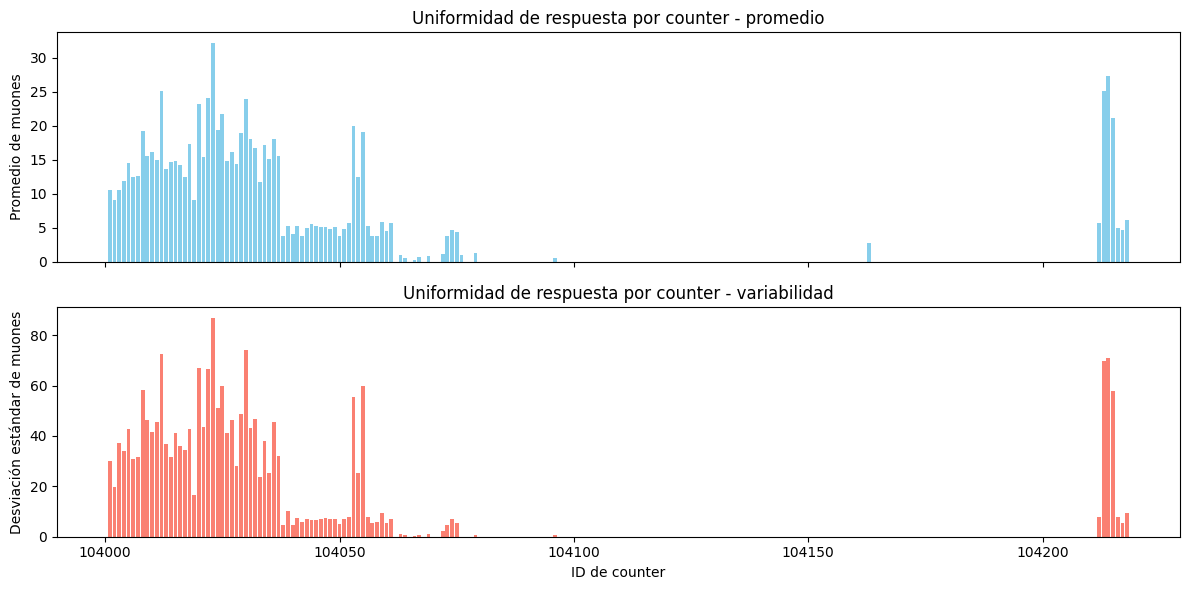

In [24]:
# -------------------------------
# MÉTODO NUEVO (PANDAS, 1 LÍNEA)
# -------------------------------
# Agrupa por 'counterId', toma la columna 'nMuones' y calcula 
# el promedio, la desviación estándar y el conteo para cada counter.
counter_stats = df_new.groupby('counterId')['nMuones'].agg(
    promedio='mean', 
    std_dev='std',
    cantidad='count'
).reset_index()

print("Estadísticos por counter:")
print(counter_stats.head())

# -------------------------------
# Visualización (adaptada al nuevo DataFrame)
# -------------------------------
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Promedio
axs[0].bar(counter_stats['counterId'], counter_stats['promedio'], color='skyblue')
axs[0].set_ylabel("Promedio de muones")
axs[0].set_title("Uniformidad de respuesta por counter - promedio")

# Desviación estándar
axs[1].bar(counter_stats['counterId'], counter_stats['std_dev'], color='salmon')
axs[1].set_ylabel("Desviación estándar de muones")
axs[1].set_xlabel("ID de counter")
axs[1].set_title("Uniformidad de respuesta por counter - variabilidad")

plt.tight_layout()
plt.show()

Rango de Theta en los datos: [1.63°, 65.29°]
Bordes de bins en Theta (grados): [ 0.         21.71553123 31.55098231 39.85570743 47.73117785 55.8266607
 65.        ]
Ploteando bin 0: Mapa polar, $\theta \approx$ [0.0°, 21.7°]


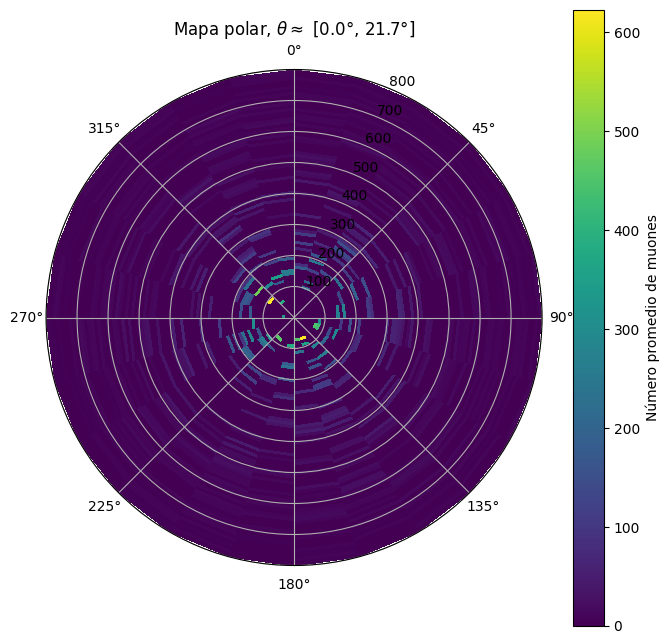

Ploteando bin 1: Mapa polar, $\theta \approx$ [21.7°, 31.6°]


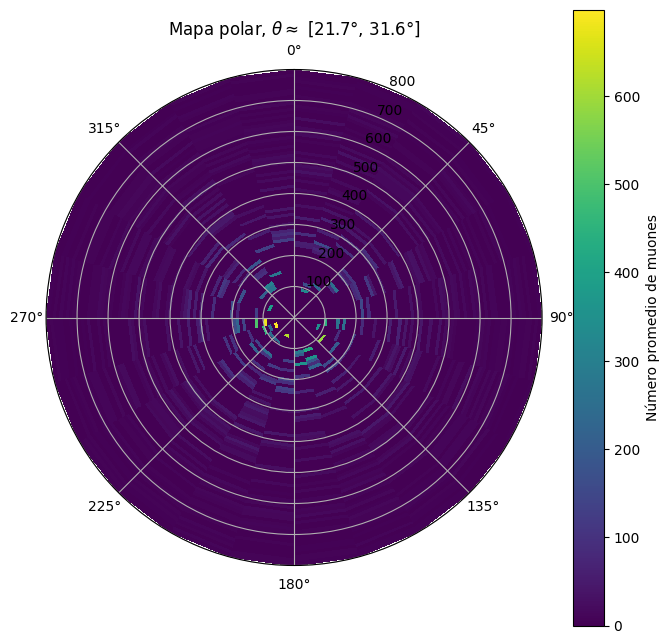

Ploteando bin 2: Mapa polar, $\theta \approx$ [31.6°, 39.9°]


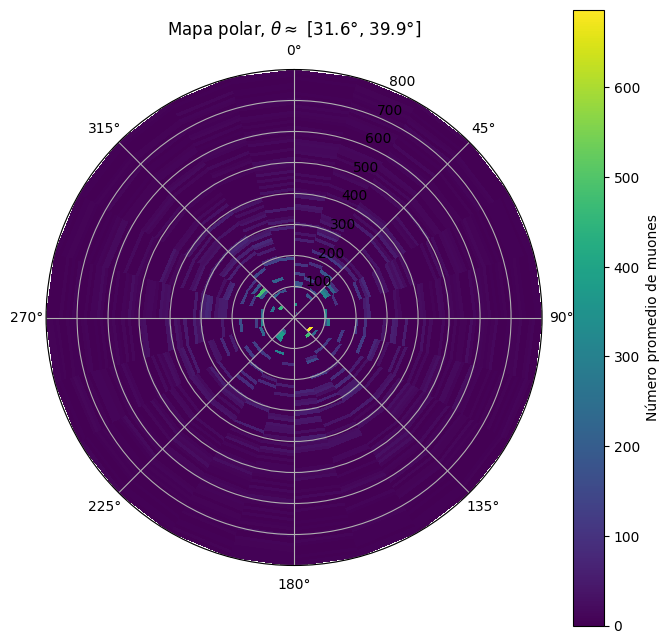

Ploteando bin 3: Mapa polar, $\theta \approx$ [39.9°, 47.7°]


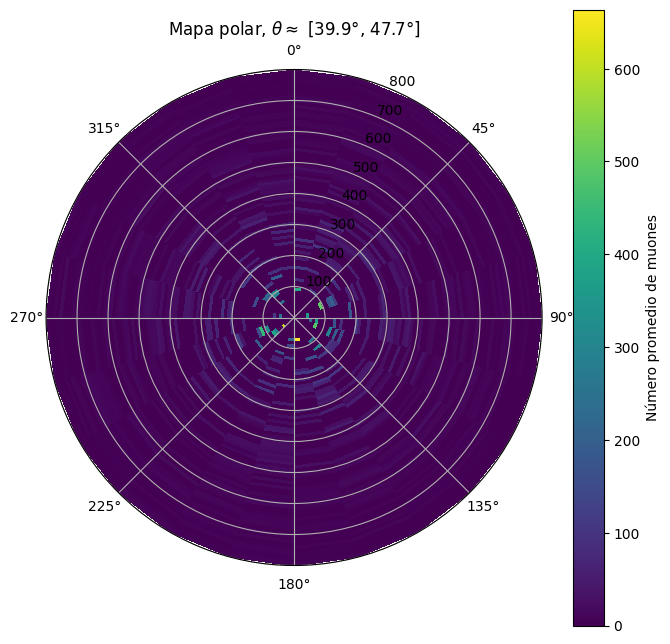

Ploteando bin 4: Mapa polar, $\theta \approx$ [47.7°, 55.8°]


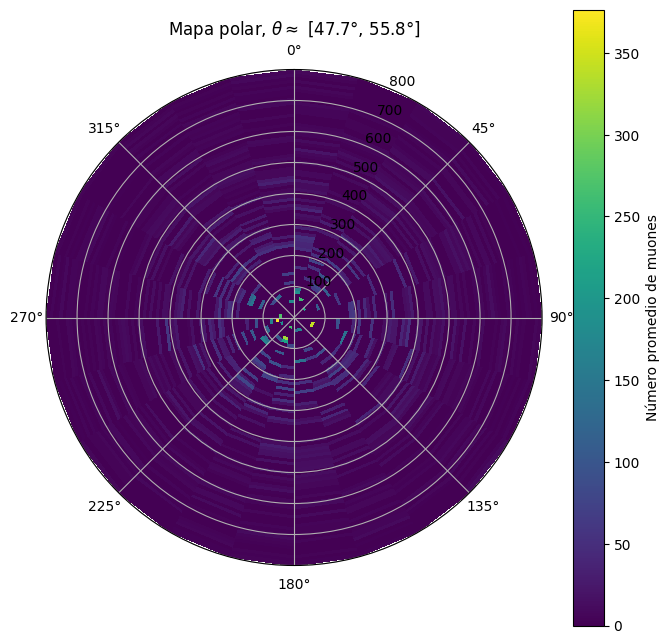

Ploteando bin 5: Mapa polar, $\theta \approx$ [55.8°, 65.0°]


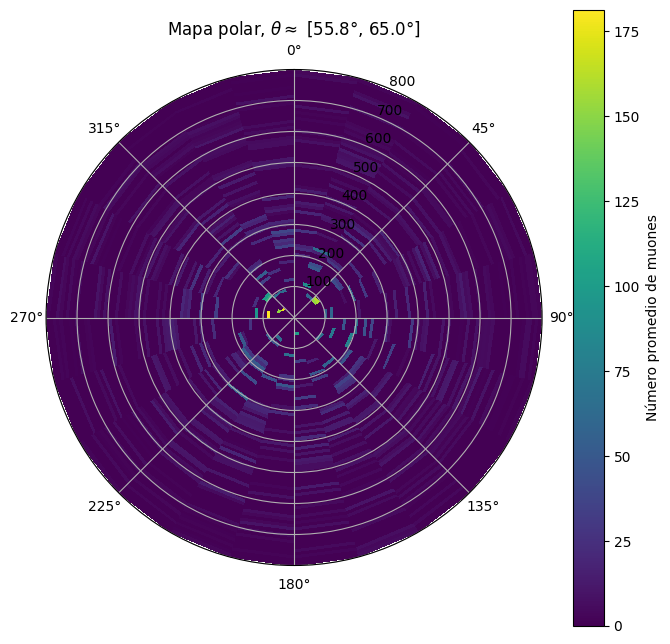

In [25]:
# --- 3. MAPA POLAR (usando df_new) ---

# -------------------------------
# Parámetros de binning (r y phi)
# -------------------------------
r_max = 800
r_bin_size = 10
phi_bins = 24 # 100 es demasiado para ver asimetrías, 12 o 24 es mejor

r_bins = np.arange(0, r_max + r_bin_size, r_bin_size)
phi_edges = np.linspace(0, 2*np.pi, phi_bins + 1)
R, Phi = np.meshgrid(r_bins, phi_edges) # Meshgrid para el plot

# -------------------------------
# Binning en sin^2(theta)
# -------------------------------
N_theta_bins = 6
theta_min_deg = 0
theta_max_deg = 65

# Verificamos el rango real
theta_min_real = df_new['theta_REC'].min()
theta_max_real = df_new['theta_REC'].max()
print(f"Rango de Theta en los datos: [{theta_min_real:.2f}°, {theta_max_real:.2f}°]")
# Usamos el máximo real si es menor a 65
theta_max_deg = min(theta_max_deg, theta_max_real) 

# 1. Crear los bins en el espacio de sin^2(theta)
s2_min = np.sin(np.deg2rad(theta_min_deg))**2
s2_max = np.sin(np.deg2rad(theta_max_deg))**2
s2_bins = np.linspace(s2_min, s2_max, N_theta_bins + 1)

# 2. Convertir los bordes de los bins de vuelta a grados (para las etiquetas)
theta_bins_deg = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))

print(f"Bordes de bins en Theta (grados): {theta_bins_deg}")

# 3. Asignar cada FILA (counter) a un bin de theta
# Convertimos theta_REC a sin^2(theta) para binear
df_new['s2_theta'] = np.sin(np.deg2rad(df_new['theta_REC']))**2
# pd.cut asigna cada fila a un bin
# (labels=False nos da un índice: 0, 1, 2, 3, 4, 5)
df_new['theta_bin'] = pd.cut(df_new['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)

# -------------------------------
# Iterar sobre cada bin de theta
# -------------------------------
# Filtramos datos malos de una vez
df_mapa_total = df_new[
    (df_new['r_core'].between(0, r_max)) &
    (df_new['nMuones'].notna()) &
    (df_new['phi_plane'].notna())
].copy()


for i in range(N_theta_bins):
    
    # Seleccionar solo las filas de este bin de theta
    df_bin = df_mapa_total[df_mapa_total['theta_bin'] == i]
    
    if df_bin.empty:
        print(f"Sin datos para el bin de theta {i}. Saltando.")
        continue

    # Título para el plot
    th_min_label = theta_bins_deg[i]
    th_max_label = theta_bins_deg[i+1]
    plot_title = f"Mapa polar, $\\theta \\approx$ [{th_min_label:.1f}°, {th_max_label:.1f}°]"
    print(f"Ploteando bin {i}: {plot_title}")

    # -------------------------------
    # Llenado de la grilla (¡VECTORIZADO!)
    # -------------------------------
    
    # Z = Suma de nMuones en cada bin (r, phi)
    Z, _, _ = np.histogram2d(
        x=df_bin['r_core'],
        y=df_bin['phi_plane'],
        bins=[r_bins, phi_edges],
        weights=df_bin['nMuones']
    )

    # counts = Número de entradas en cada bin (r, phi)
    counts, _, _ = np.histogram2d(
        x=df_bin['r_core'],
        y=df_bin['phi_plane'],
        bins=[r_bins, phi_edges]
    )

    # Transponemos porque pcolormesh espera (phi, r)
    Z_T = Z.T
    counts_T = counts.T

    # Promedio de muones por bin
    Z_avg = np.divide(Z_T, counts_T, out=np.zeros_like(Z_T), where=counts_T != 0)

    # -------------------------------
    # Plot polar
    # -------------------------------
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    c = ax.pcolormesh(Phi, R, Z_avg, cmap='viridis', shading='auto')
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlim(0, r_max)
    fig.colorbar(c, ax=ax, label="Número promedio de muones")
    plt.title(plot_title)
    plt.show()

# Analisis de todos los datos juntos

In [2]:
# --- 1. Definir la carpeta donde están los Parquet ---
parquet_dir = "ADST_Alexey_por_module/parquet/"

# --- 2. Encontrar todos los archivos .parquet ---
# Usamos el comodín * para encontrar todos los archivos que terminen en .parquet
all_parquet_files = glob.glob(os.path.join(parquet_dir, "*.parquet"))
all_parquet_files.sort() # Opcional, pero bueno para el orden

print(f"Encontrados {len(all_parquet_files)} archivos .parquet en la carpeta.")

# --- 3. Leer y concatenar todos los archivos ---
if not all_parquet_files:
    print("¡Error! No se encontraron archivos. Verifica la ruta 'parquet_dir'.")
else:
    df_list = [] # Lista para guardar cada DataFrame individual
    for fpath in all_parquet_files:
        print(f"Leyendo: {os.path.basename(fpath)}...")
        df_temp = pd.read_parquet(fpath)
        df_list.append(df_temp)

    # ¡Juntamos todos los DataFrames de la lista en uno solo!
    df_new = pd.concat(df_list, ignore_index=True)

    # --- 4. Limpieza (la misma que tenías) ---
    df_new.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_new.dropna(subset=['logE_REC'], inplace=True)

    print("\n¡Concatenación completa!")
    print(f"DataFrame 'df_new' (mega) cargado con {len(df_new)} filas (counters).")
    print(df_new.head())

Encontrados 20 archivos .parquet en la carpeta.
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run010.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run011.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run012.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run013.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run014.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run030.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run031.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run032.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run033.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run034.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run080.parquet...
Leyendo: SIB23e_175_180_helium_MdSdInfill_CORSIKA78010_FLUKA_Run081.parquet...
Leye

Generando gráfico 3D...


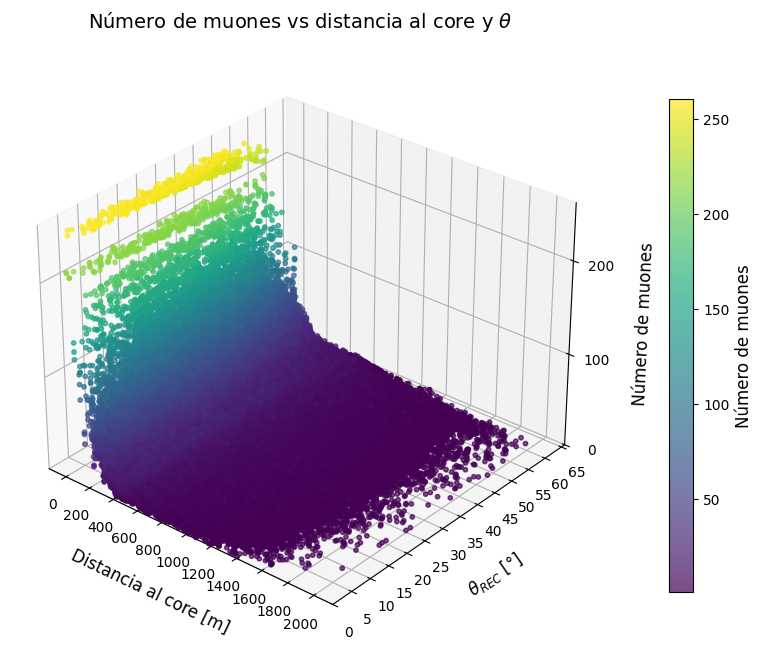

In [3]:
print("Generando gráfico 3D...")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# (Opcional) Filtremos un poco para que el plot sea más claro
# ej: sacamos counters sin muones o muy lejanos
df_plot = df_new[
    (df_new['nMuones'] > 0) &
    (df_new['r_core'] < 2000) # (Ajustá este límite si es necesario)
]

# Scatter
sc = ax.scatter(
    df_plot["r_core"],
    df_plot["theta_REC"],  # <-- Columna renombrada
    df_plot["nMuones"],
    c=df_plot["nMuones"], 
    cmap="viridis", 
    alpha=0.7,
    s=10 # Hago los puntos un poco más chicos
)

# Labels
ax.set_xlabel("Distancia al core [m]", fontsize=12, labelpad=10)
ax.set_ylabel(r"$\theta_{REC}$ [°]", fontsize=12, labelpad=10) # <-- Label actualizado
ax.set_zlabel("Número de muones", fontsize=12, labelpad=10)
plt.title(r"Número de muones vs distancia al core y $\theta$", fontsize=14, pad=20)

# Mejorar ticks (usando tu configuración)
ax.set_xticks(np.arange(0, 2000 + 1, 200))
ax.set_yticks(np.arange(0, 66 + 1, 5))
ax.set_ylim(0, 66) # (Tal vez quieras subir este límite si tus datos llegan a 60°)

# Zticks: Usar un log-scale o binear puede ser mejor
# pero siguiendo tu código original:
z_max = df_plot["nMuones"].max()
ax.set_zticks(np.arange(0, z_max + 1, 100)) # Ajustado a 100, ya que 50 era muy denso
ax.set_zlim(0, z_max) # Asegurarse de que el eje Z llegue al máximo

# Añadir barra de color
cbar = plt.colorbar(sc, pad=0.1, shrink=0.8)
cbar.set_label("Número de muones", fontsize=12)

# Rotar la vista
ax.view_init(elev=30, azim=310)

# Grid
ax.grid(True)

plt.show()

In [4]:
# --- Celda para crear df_events ---

# (Asegurarse de que df_new esté cargado)
print(f"DataFrame 'df_new' (módulos) cargado con {len(df_new)} filas.")

# 1. Columnas que son únicas por evento
event_cols = [
    "run_number",
    "event_id",
    "logE_MC", "theta_MC", "phi_MC", "primary",
    "logE_REC", "theta_REC", "phi_REC"
]

# 2. Crear el DataFrame de eventos únicos
# Usamos drop_duplicates() para colapsar las ~67 filas de cada evento en UNA sola.
df_events = df_new[event_cols].drop_duplicates()

print(f"DataFrame 'df_events' (lluvias) creado con {len(df_events)} filas únicas.")
df_events.head()

DataFrame 'df_new' (módulos) cargado con 1564017 filas.
DataFrame 'df_events' (lluvias) creado con 23332 filas únicas.


,run_number,event_id,logE_MC,theta_MC,phi_MC,primary,logE_REC,theta_REC,phi_REC
0,10,Library_Prague_Santos_Yushkov:Run_10000:Shower...,17.557002,10.497525,266.129022,He,17.424415,9.516247,269.459517
57,10,Library_Prague_Santos_Yushkov:Run_10001:Shower...,17.514259,3.048157,315.899666,He,17.423894,3.140957,323.483553
117,10,Library_Prague_Santos_Yushkov:Run_10002:Shower...,17.509618,28.251578,331.123960,He,17.406819,27.135014,331.405738
180,10,Library_Prague_Santos_Yushkov:Run_10003:Shower...,17.896363,36.831416,117.406958,He,17.780786,36.541166,118.938084
255,10,Library_Prague_Santos_Yushkov:Run_10004:Shower...,17.755350,53.969303,169.547926,He,17.587915,53.550577,168.552741


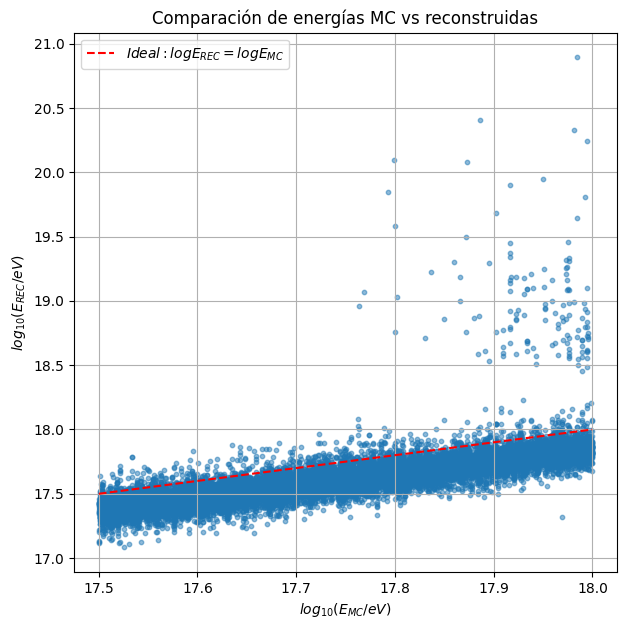

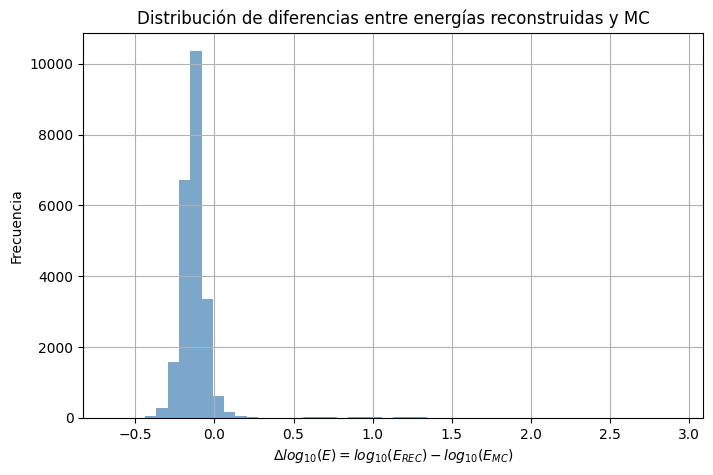

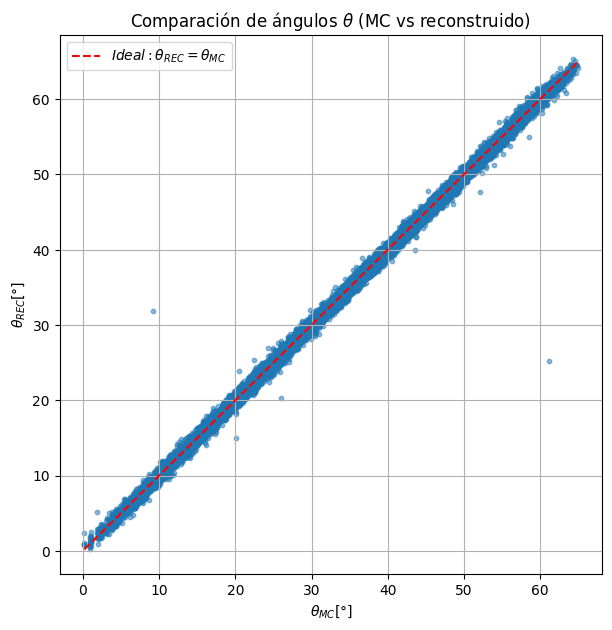

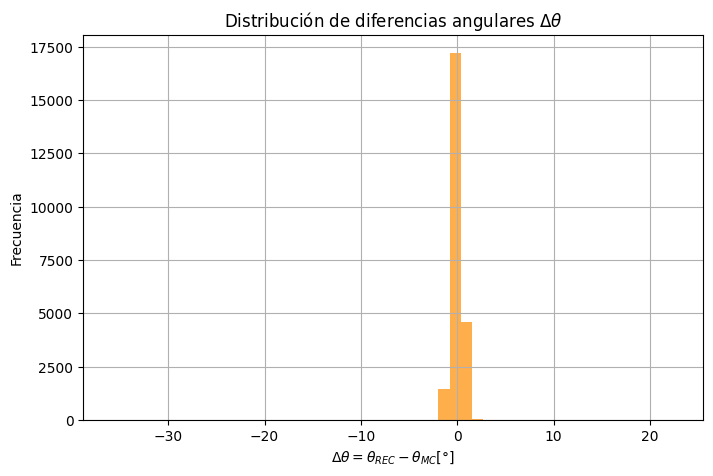

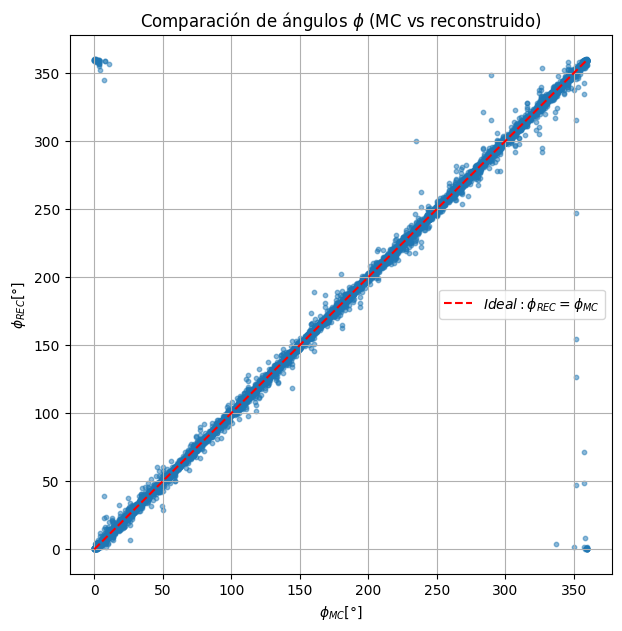

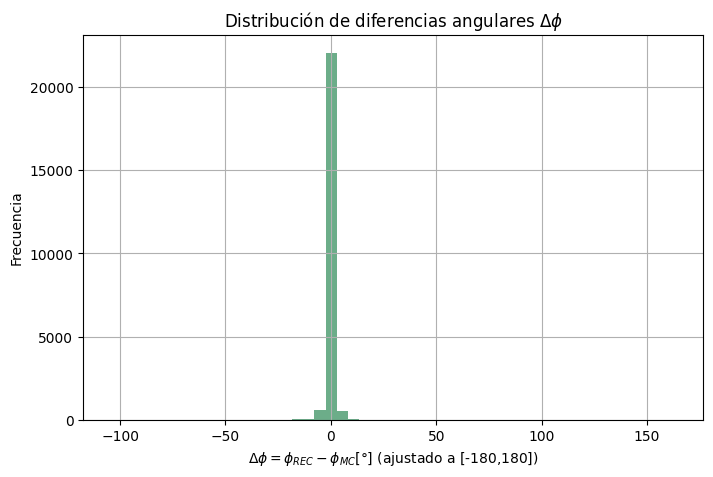

=== Energía (log10) ===
Promedio ΔlogE: -0.1270
Desviación estándar ΔlogE: 0.1179

=== Ángulo cenital θ ===
Promedio Δθ: -0.0413°
Desviación estándar Δθ: 0.5828°

=== Ángulo azimutal φ ===
Mediana Δφ: 0.0105°
MAD Δφ: 0.5599°


In [5]:
# --- 1. PLOTS DE RESOLUCIÓN (usando df_events) ---

# -------------------------------
# Comparar logE_MC vs logE_REC
# -------------------------------
plt.figure(figsize=(7, 7))
# ❗️ CAMBIO: df_all -> df_events
plt.scatter(df_events["logE_MC"], df_events["logE_REC"], s=10, alpha=0.5)
plt.plot([df_events["logE_MC"].min(), df_events["logE_MC"].max()],
         [df_events["logE_MC"].min(), df_events["logE_MC"].max()],
         'r--', label=r"$Ideal: logE_{REC} = logE_{MC}$")

plt.xlabel(r"$log_{10}(E_{MC} / eV)$")
plt.ylabel(r"$log_{10}(E_{REC} / eV)$")
plt.title("Comparación de energías MC vs reconstruidas")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Diferencia ΔlogE = logE_REC - logE_MC
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
deltaE = df_events["logE_REC"] - df_events["logE_MC"]
# (El resto de tu código de histograma es idéntico)
plt.figure(figsize=(8, 5))
plt.hist(deltaE.dropna(), bins=50, alpha=0.7, color='steelblue') # .dropna() por seguridad
plt.xlabel(r"$\Delta log_{10}(E) = log_{10}(E_{REC}) - log_{10}(E_{MC})$")
plt.ylabel("Frecuencia")
plt.title("Distribución de diferencias entre energías reconstruidas y MC")
plt.grid(True)
plt.show()

# -------------------------------
# THETA
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
plt.figure(figsize=(7,7))
plt.scatter(df_events["theta_MC"], df_events["theta_REC"], s=10, alpha=0.5)
plt.plot([df_events["theta_MC"].min(), df_events["theta_MC"].max()],
         [df_events["theta_MC"].min(), df_events["theta_MC"].max()],
         'r--', label=r"$Ideal: \theta_{REC} = \theta_{MC}$")
plt.xlabel(r"$\theta_{MC} [°]$")
plt.ylabel(r"$\theta_{REC} [°]$")
plt.title(r"Comparación de ángulos $\theta$ (MC vs reconstruido)")
plt.legend()
plt.grid(True)
plt.show()

# ❗️ CAMBIO: df_all -> df_events
delta_theta = df_events["theta_REC"] - df_events["theta_MC"]

plt.figure(figsize=(8,5))
plt.hist(delta_theta.dropna(), bins=50, alpha=0.7, color='darkorange') # .dropna()
plt.xlabel(r"$\Delta \theta = \theta_{REC} - \theta_{MC} [°]$")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de diferencias angulares $\Delta \theta$")
plt.grid(True)
plt.show()

# -------------------------------
# PHI
# -------------------------------
# ❗️ CAMBIO: df_all -> df_events
plt.figure(figsize=(7,7))
plt.scatter(df_events["phi_MC"], df_events["phi_REC"], s=10, alpha=0.5)
plt.plot([df_events["phi_MC"].min(), df_events["phi_MC"].max()],
         [df_events["phi_MC"].min(), df_events["phi_MC"].max()],
         'r--', label=r"$Ideal: \phi_{REC} = \phi_{MC}$")
plt.xlabel(r"$\phi_{MC} [°]$")
plt.ylabel(r"$\phi_{REC} [°]$")
plt.title(r"Comparación de ángulos $\phi$ (MC vs reconstruido)")
plt.legend()
plt.grid(True)
plt.show()

# Cuidar el wrap-around de phi (0–360)
# ❗️ CAMBIO: df_all -> df_events
delta_phi = (df_events["phi_REC"] - df_events["phi_MC"] + 180) % 360 - 180

plt.figure(figsize=(8,5))
plt.hist(delta_phi.dropna(), bins=50, alpha=0.7, color='seagreen') # .dropna()
plt.xlabel(r"$\Delta \phi = \phi_{REC} - \phi_{MC} [°]$ (ajustado a [-180,180])")
plt.ylabel("Frecuencia")
plt.title(r"Distribución de diferencias angulares $\Delta \phi$")
plt.grid(True)
plt.show()

# -------------------------------
# Resumen de Métricas
# -------------------------------
# Mediana y MAD de Δφ
median_phi = np.median(delta_phi.dropna())
mad_phi = np.median(np.abs(delta_phi.dropna() - median_phi))

print("=== Energía (log10) ===")
print(f"Promedio ΔlogE: {deltaE.mean():.4f}")
print(f"Desviación estándar ΔlogE: {deltaE.std():.4f}\n")

print("=== Ángulo cenital θ ===")
print(f"Promedio Δθ: {delta_theta.mean():.4f}°")
print(f"Desviación estándar Δθ: {delta_theta.std():.4f}°\n")

print("=== Ángulo azimutal φ ===")
print(f"Mediana Δφ: {median_phi:.4f}°")
print(f"MAD Δφ: {mad_phi:.4f}°")

Estadísticos por counter (sumando módulos):
   counterId   promedio    std_dev  cantidad
0      90000  90.615269  42.908798      4838
1      90001  89.645316  42.610912      4842
2      90002  87.185551  41.770549      4841
3      90003  84.460448  40.804006      4832
4      90004  81.720445  40.371472      4835


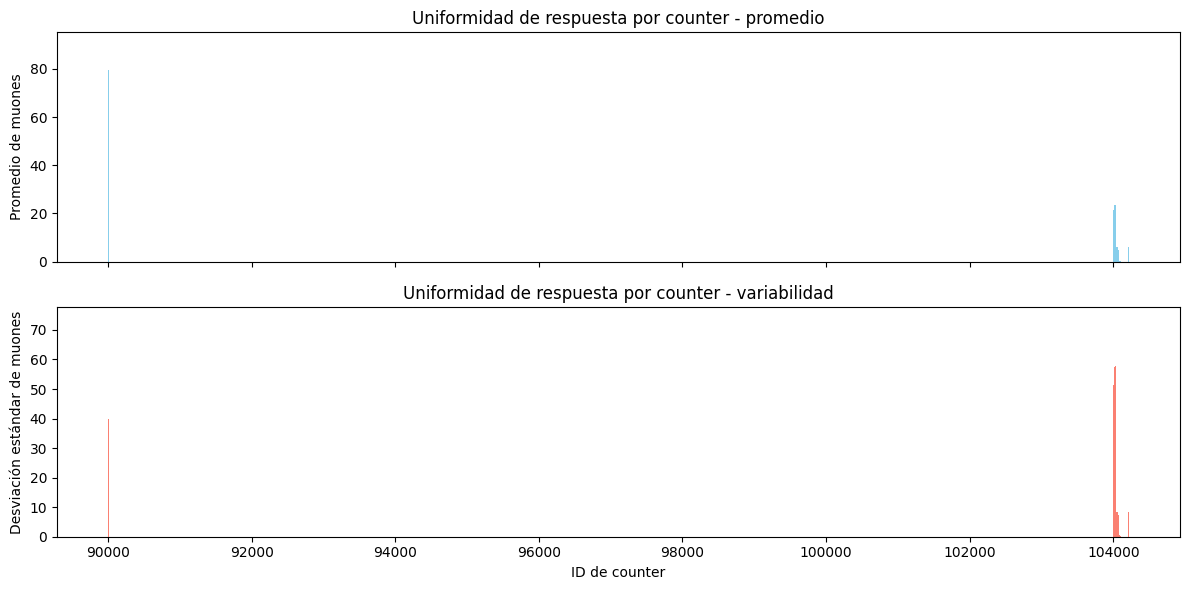

In [6]:
# --- Uniformidad por COUNTER (Nuevo método) ---

# 1. Agrupamos por evento Y counter, y sumamos los nMuones de los módulos
df_counters = df_new.groupby(['event_id', 'counterId'])['nMuones'].sum().reset_index()

# 2. Ahora sí, hacemos el groupby sobre este nuevo df_counters
counter_stats = df_counters.groupby('counterId')['nMuones'].agg(
    promedio='mean', 
    std_dev='std',
    cantidad='count'
).reset_index()

print("Estadísticos por counter (sumando módulos):")
print(counter_stats.head())

# -------------------------------
# Visualización (adaptada al nuevo DataFrame)
# -------------------------------
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Promedio
axs[0].bar(counter_stats['counterId'], counter_stats['promedio'], color='skyblue')
axs[0].set_ylabel("Promedio de muones")
axs[0].set_title("Uniformidad de respuesta por counter - promedio")

# Desviación estándar
axs[1].bar(counter_stats['counterId'], counter_stats['std_dev'], color='salmon')
axs[1].set_ylabel("Desviación estándar de muones")
axs[1].set_xlabel("ID de counter")
axs[1].set_title("Uniformidad de respuesta por counter - variabilidad")

plt.tight_layout()
plt.show()

Rango de Theta en los datos: [0.22°, 65.29°]
Bordes de bins en Theta (grados): [ 0.         21.76911976 31.63362425 39.96810814 47.87939805 56.02532269
 65.29007814]
Ploteando bin 0: Mapa polar, $\theta \approx$ [0.0°, 21.8°]


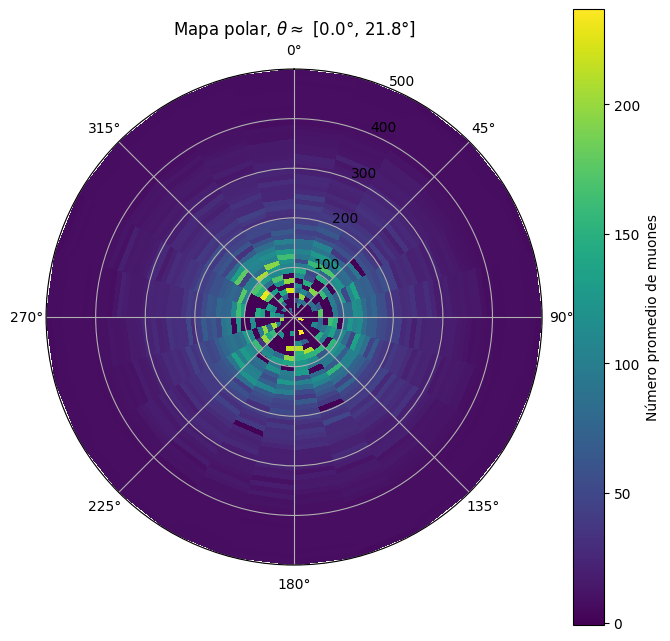

Ploteando bin 1: Mapa polar, $\theta \approx$ [21.8°, 31.6°]


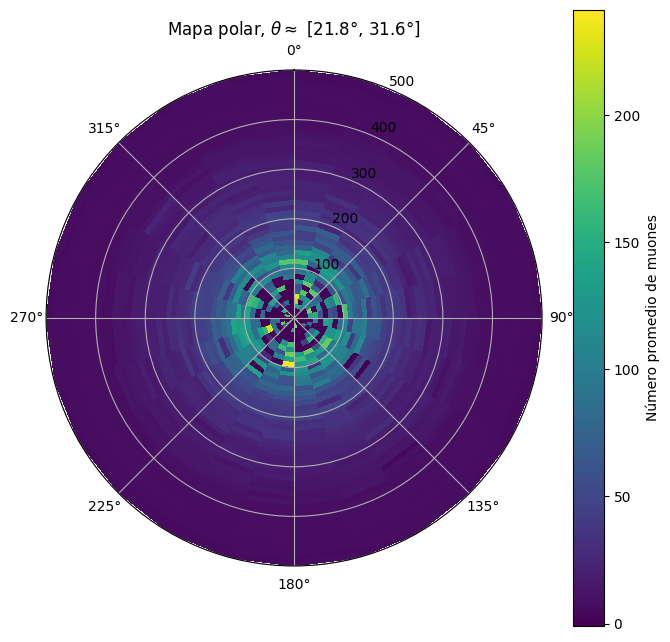

Ploteando bin 2: Mapa polar, $\theta \approx$ [31.6°, 40.0°]


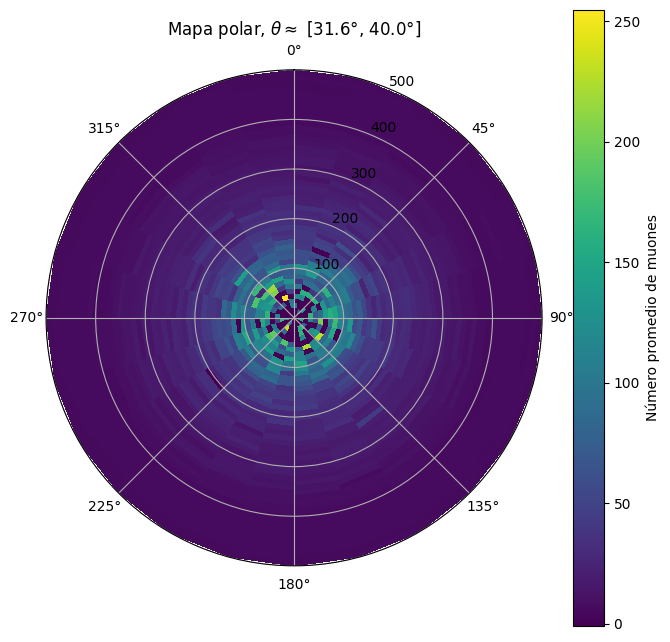

Ploteando bin 3: Mapa polar, $\theta \approx$ [40.0°, 47.9°]


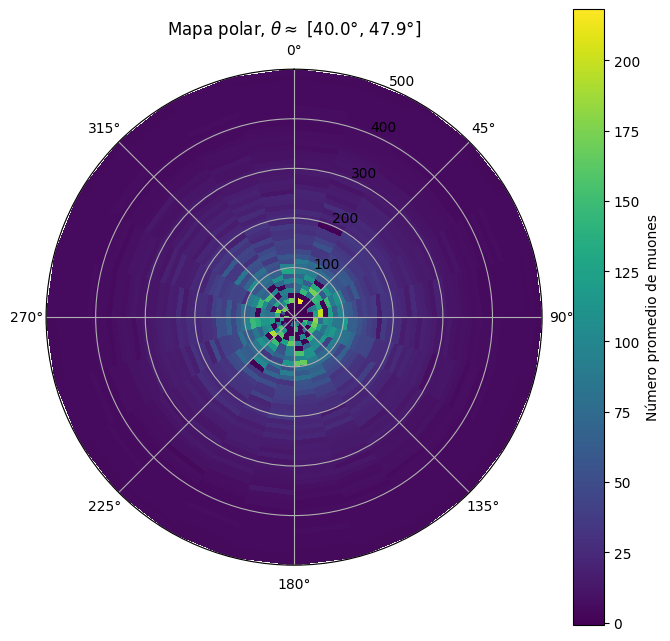

Ploteando bin 4: Mapa polar, $\theta \approx$ [47.9°, 56.0°]


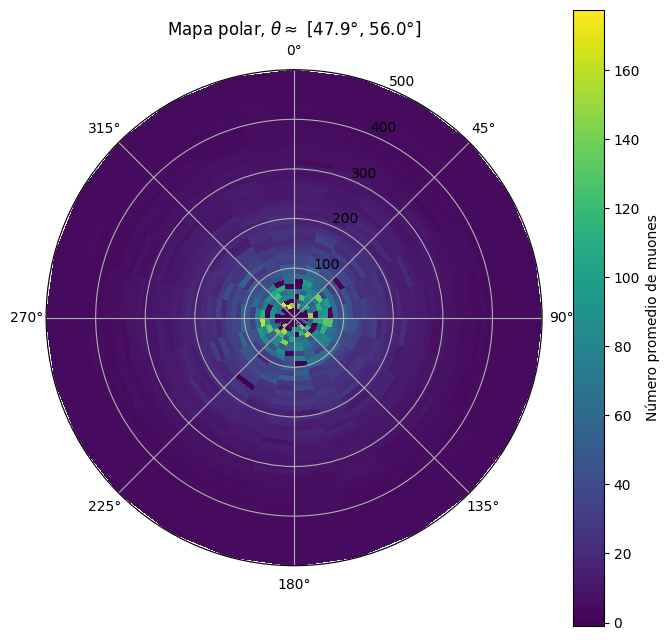

Ploteando bin 5: Mapa polar, $\theta \approx$ [56.0°, 65.3°]


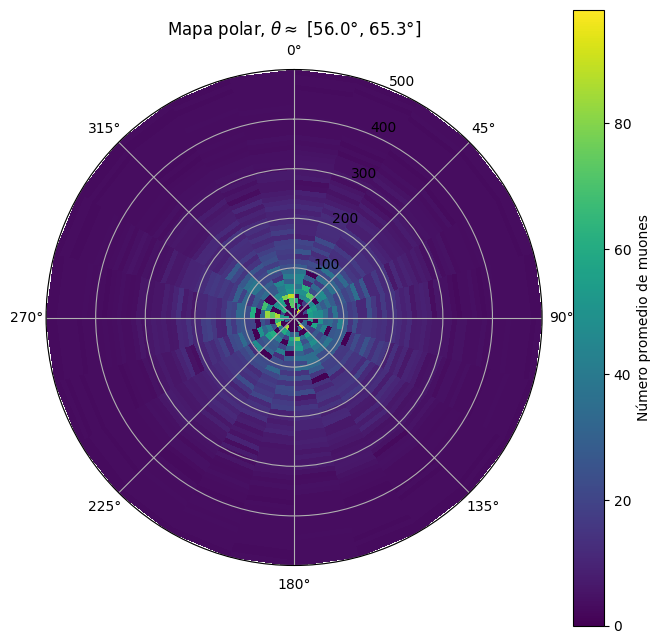

In [7]:
# --- 3. MAPA POLAR (usando df_new) ---

# -------------------------------
# Parámetros de binning (r y phi)
# -------------------------------
r_max = 500
r_bin_size = 10
phi_bins = 24 # 100 es demasiado para ver asimetrías, 12 o 24 es mejor

r_bins = np.arange(0, r_max + r_bin_size, r_bin_size)
phi_edges = np.linspace(0, 2*np.pi, phi_bins + 1)
R, Phi = np.meshgrid(r_bins, phi_edges) # Meshgrid para el plot

# -------------------------------
# Binning en sin^2(theta)
# -------------------------------
N_theta_bins = 6
theta_min_deg = 0
theta_max_deg = 66

# Verificamos el rango real
theta_min_real = df_new['theta_REC'].min()
theta_max_real = df_new['theta_REC'].max()
print(f"Rango de Theta en los datos: [{theta_min_real:.2f}°, {theta_max_real:.2f}°]")
# Usamos el máximo real si es menor a 65
theta_max_deg = min(theta_max_deg, theta_max_real) 

# 1. Crear los bins en el espacio de sin^2(theta)
s2_min = np.sin(np.deg2rad(theta_min_deg))**2
s2_max = np.sin(np.deg2rad(theta_max_deg))**2
s2_bins = np.linspace(s2_min, s2_max, N_theta_bins + 1)

# 2. Convertir los bordes de los bins de vuelta a grados (para las etiquetas)
theta_bins_deg = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))

print(f"Bordes de bins en Theta (grados): {theta_bins_deg}")

# 3. Asignar cada FILA (counter) a un bin de theta
# Convertimos theta_REC a sin^2(theta) para binear
df_new['s2_theta'] = np.sin(np.deg2rad(df_new['theta_REC']))**2
# pd.cut asigna cada fila a un bin
# (labels=False nos da un índice: 0, 1, 2, 3, 4, 5)
df_new['theta_bin'] = pd.cut(df_new['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)

# -------------------------------
# Iterar sobre cada bin de theta
# -------------------------------
# Filtramos datos malos de una vez
df_mapa_total = df_new[
    (df_new['r_core'].between(0, r_max)) &
    (df_new['nMuones'].notna()) &
    (df_new['phi_plane'].notna())
].copy()


for i in range(N_theta_bins):
    
    # Seleccionar solo las filas de este bin de theta
    df_bin = df_mapa_total[df_mapa_total['theta_bin'] == i]
    
    if df_bin.empty:
        print(f"Sin datos para el bin de theta {i}. Saltando.")
        continue

    # Título para el plot
    th_min_label = theta_bins_deg[i]
    th_max_label = theta_bins_deg[i+1]
    plot_title = rf"Mapa polar, $\theta \approx$ [{th_min_label:.1f}°, {th_max_label:.1f}°]"
    print(f"Ploteando bin {i}: {plot_title}")

    # -------------------------------
    # Llenado de la grilla (¡VECTORIZADO!)
    # -------------------------------
    
    # Z = Suma de nMuones en cada bin (r, phi)
    Z, _, _ = np.histogram2d(
        x=df_bin['r_core'],
        y=df_bin['phi_plane'],
        bins=[r_bins, phi_edges],
        weights=df_bin['nMuones']
    )

    # counts = Número de entradas en cada bin (r, phi)
    counts, _, _ = np.histogram2d(
        x=df_bin['r_core'],
        y=df_bin['phi_plane'],
        bins=[r_bins, phi_edges]
    )

    # Transponemos porque pcolormesh espera (phi, r)
    Z_T = Z.T
    counts_T = counts.T

    # Promedio de muones por bin
    Z_avg = np.divide(Z_T, counts_T, out=np.zeros_like(Z_T), where=counts_T != 0)

    # -------------------------------
    # Plot polar
    # -------------------------------
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    c = ax.pcolormesh(Phi, R, Z_avg, cmap='viridis', shading='auto')
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlim(0, r_max)
    fig.colorbar(c, ax=ax, label="Número promedio de muones")
    plt.title(plot_title)
    plt.show()

# Cortes bineados por r y tita

Bordes de bins en Theta (grados): [ 0.  21.7 31.6 39.9 47.7 55.8 65. ]

Analizando asimetría en el anillo r = [400, 500] m
Procesando bin de theta 0: 2592 counters encontrados.


/tmp/ipykernel_283174/2102674847.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


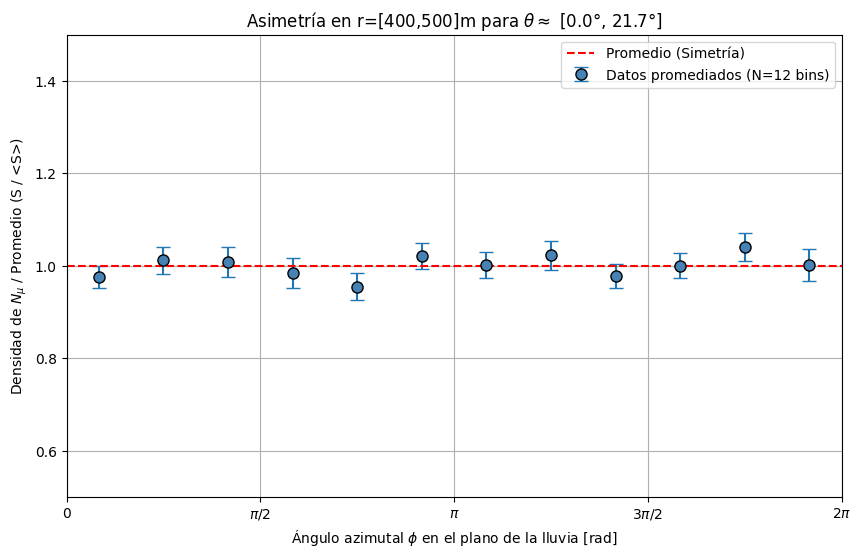

Procesando bin de theta 1: 2486 counters encontrados.


/tmp/ipykernel_283174/2102674847.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


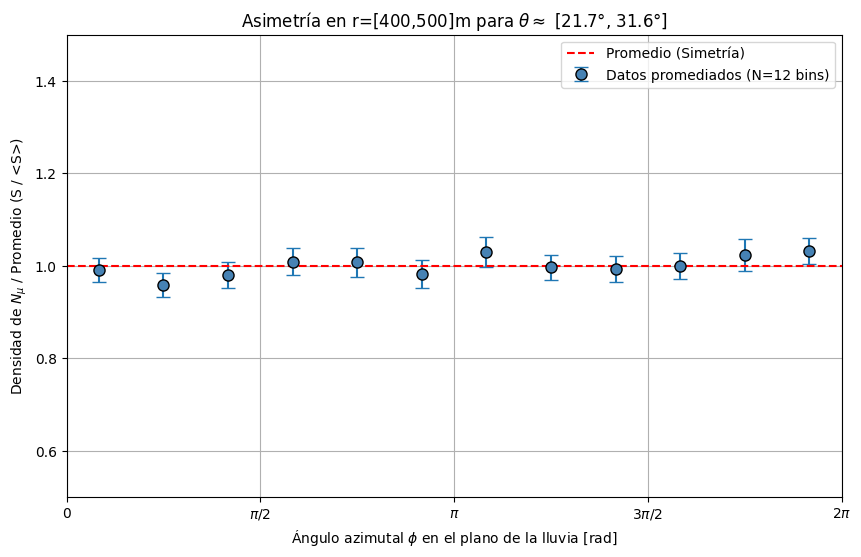

Procesando bin de theta 2: 2826 counters encontrados.


/tmp/ipykernel_283174/2102674847.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


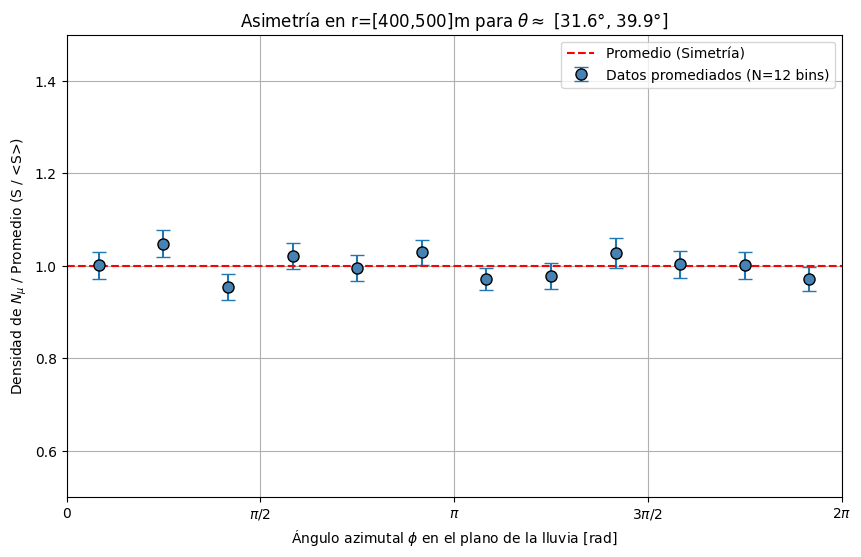

Procesando bin de theta 3: 3262 counters encontrados.


/tmp/ipykernel_283174/2102674847.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


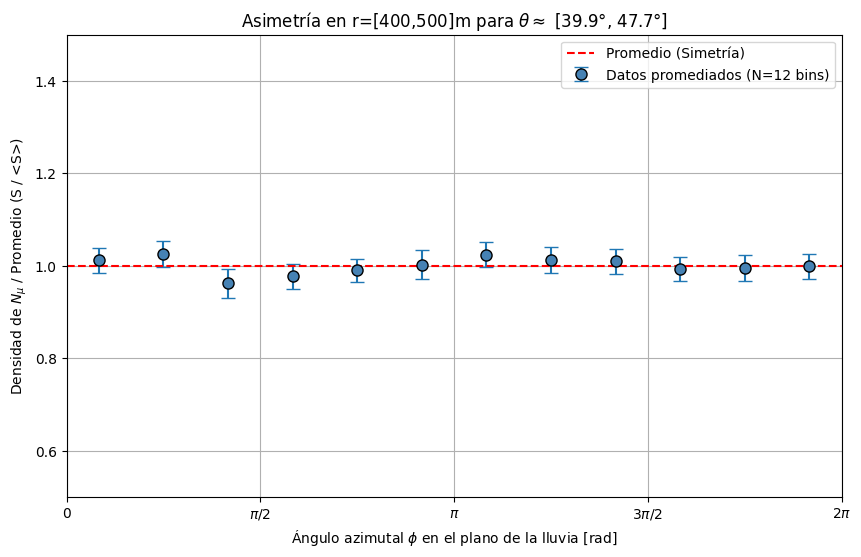

Procesando bin de theta 4: 3844 counters encontrados.


/tmp/ipykernel_283174/2102674847.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


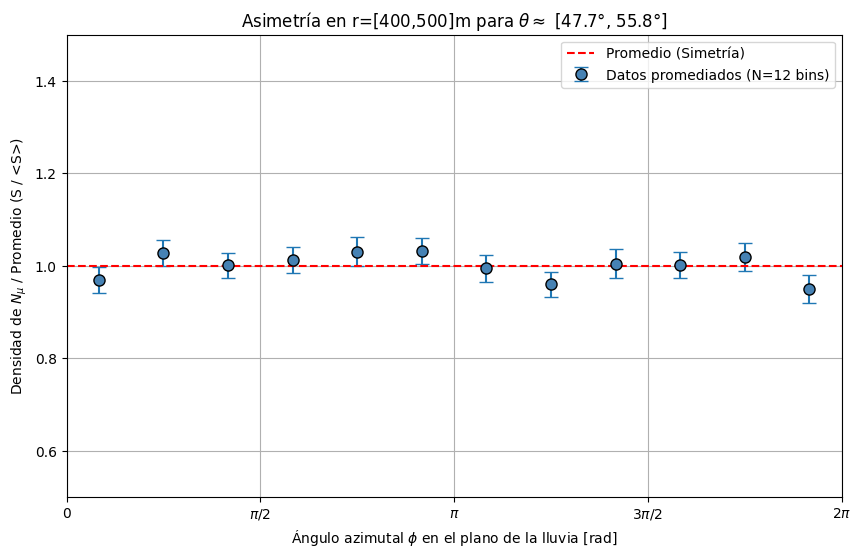

Procesando bin de theta 5: 2908 counters encontrados.


/tmp/ipykernel_283174/2102674847.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


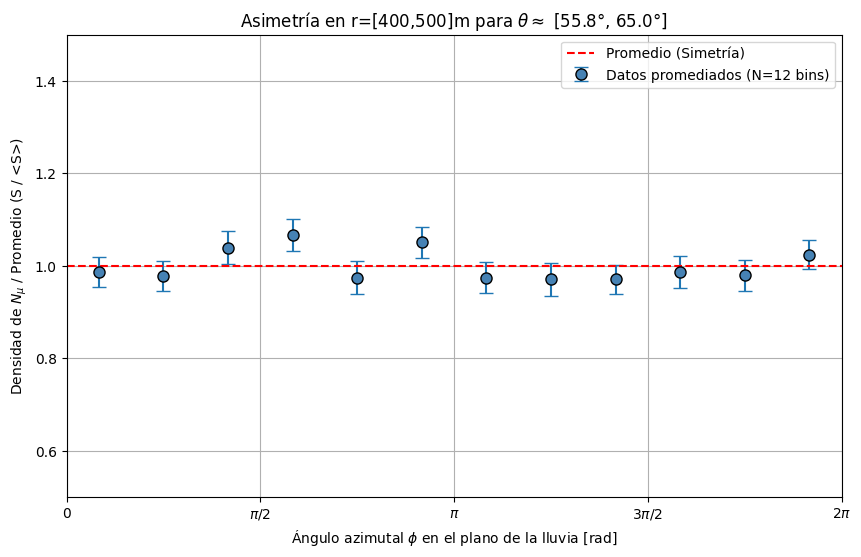

In [9]:
# --- 1. Parámetros de binning (r y phi) ---
r_min = 400
r_max = 500
phi_plot_bins = 12

phi_bin_edges = np.linspace(0, 2 * np.pi, phi_plot_bins + 1)
# ❗️ CAMBIO: Creamos "labels" para los bins, del 0 al 11
phi_bin_labels = range(phi_plot_bins)
# Centros de los bins (sigue igual)
phi_bin_centers = (phi_bin_edges[:-1] + phi_bin_edges[1:]) / 2.0

# --- 2. Parámetros de binning en sin^2(theta) ---
N_theta_bins = 6
theta_min_deg = 0
theta_max_deg = 65

theta_max_real = df_new['theta_REC'].max()
theta_max_deg = min(theta_max_deg, theta_max_real) 

s2_min = np.sin(np.deg2rad(theta_min_deg))**2
s2_max = np.sin(np.deg2rad(theta_max_deg))**2
s2_bins = np.linspace(s2_min, s2_max, N_theta_bins + 1)
theta_bins_deg = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))

print(f"Bordes de bins en Theta (grados): {np.round(theta_bins_deg, 1)}")

# Asignamos cada FILA (counter) a un bin de theta (sigue igual)
df_new['s2_theta'] = np.sin(np.deg2rad(df_new['theta_REC']))**2
df_new['theta_bin'] = pd.cut(df_new['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)

# --- 3. Bucle anidado (sigue igual) ---
print(f"\nAnalizando asimetría en el anillo r = [{r_min}, {r_max}] m")

for i in range(N_theta_bins):
    
    th_min_label = theta_bins_deg[i]
    th_max_label = theta_bins_deg[i+1]
    plot_title = f"Asimetría en r=[{r_min},{r_max}]m para $\\theta \\approx$ [{th_min_label:.1f}°, {th_max_label:.1f}°]"

    # --- DOBLE FILTRO (sigue igual) ---
    df_slice = df_new[
        (df_new['theta_bin'] == i) &
        (df_new['r_core'].between(r_min, r_max))
    ].copy()

    if df_slice.empty or len(df_slice) < 50:
        print(f"Datos insuficientes para el bin de theta {i}. Saltando.")
        continue
    
    print(f"Procesando bin de theta {i}: {len(df_slice)} counters encontrados.")

    # --- ❗️ CÁLCULO DE DENSIDAD (MÉTODO LEGIBLE CON GROUPBY) ---
    
    # 1. Asignamos cada counter a su bin de phi
    df_slice['phi_bin'] = pd.cut(df_slice['phi_plane'], bins=phi_bin_edges, labels=phi_bin_labels, include_lowest=True)
    
    # 2. Calculamos media, std y N (count) en un solo paso
    phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(
        mean_density='mean',  # Esto es tu "muon_density"
        std_dev='std',
        N_entries='count'     # Esto es tu "entries_per_bin"
    )
    
    # 3. Calculamos el Error Estándar de la Media (SEM)
    phi_stats['sem'] = phi_stats['std_dev'] / np.sqrt(phi_stats['N_entries'])

    # --- 4. Normalizar (S/<S>) ---
    # Calculamos el promedio global solo de los bins que tienen datos
    overall_mean_density = phi_stats['mean_density'].mean()

    phi_stats['S_norm'] = phi_stats['mean_density'] / overall_mean_density
    # ❗️ AÑADIDO: Propagamos el error a la normalización
    phi_stats['S_norm_err'] = phi_stats['sem'] / overall_mean_density
    
    # Agregamos los centros de los bins para el plot
    phi_stats['phi_center'] = phi_bin_centers

    # --- 5. Plotear con Barras de Error ---
    plt.figure(figsize=(10, 6))
    
    # ❗️ CAMBIO: Usamos plt.errorbar
    plt.errorbar(
        phi_stats['phi_center'],       # Eje X
        phi_stats['S_norm'],           # Eje Y
        yerr=phi_stats['S_norm_err'],  # ❗️ Barras de error
        fmt='o', # 'o' para puntos
        ms=8, mec='black', mfc='steelblue',
        capsize=5, # Añade "tapitas" a las barras de error
        label=f'Datos promediados (N={phi_plot_bins} bins)'
    )

    plt.xlabel(r"Ángulo azimutal $\phi$ en el plano de la lluvia [rad]")
    plt.ylabel(r"Densidad de $N_{\mu}$ / Promedio (S / <S>)")
    plt.title(plot_title)
    plt.xticks(np.linspace(0, 2*np.pi, 5), ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
    plt.xlim(0, 2 * np.pi)
    plt.ylim(0.5, 1.5)
    plt.axhline(1.0, color='r', linestyle='--', label='Promedio (Simetría)')
    plt.grid(True)
    plt.legend()
    plt.show()

Bordes de bins en Theta (grados): [ 0.  21.7 31.6 39.9 47.7 55.8 65. ]
Usando 1564017 filas (módulos) 'limpios' (de 1564017 totales)

Analizando asimetría en el anillo r = [400, 500] m
Procesando bin de theta 0: 160854 módulos encontrados.


/tmp/ipykernel_675626/2513961988.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


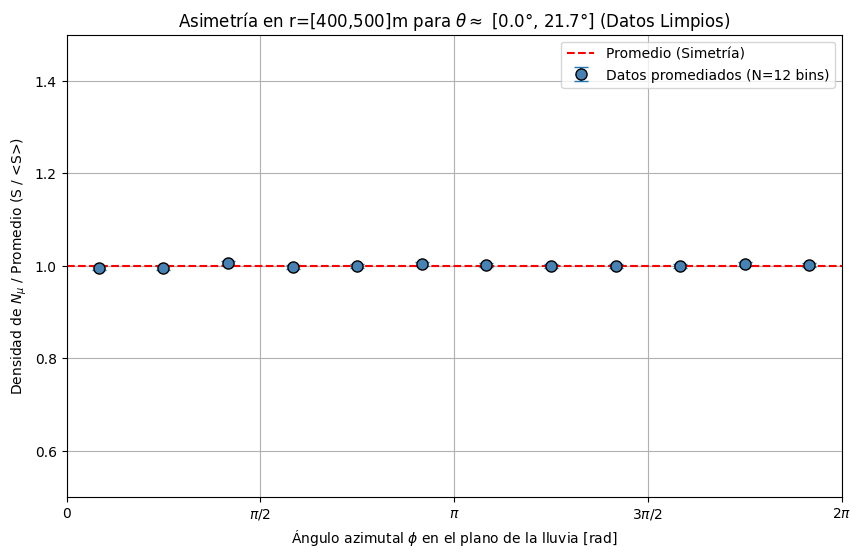

Procesando bin de theta 1: 152184 módulos encontrados.


/tmp/ipykernel_675626/2513961988.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


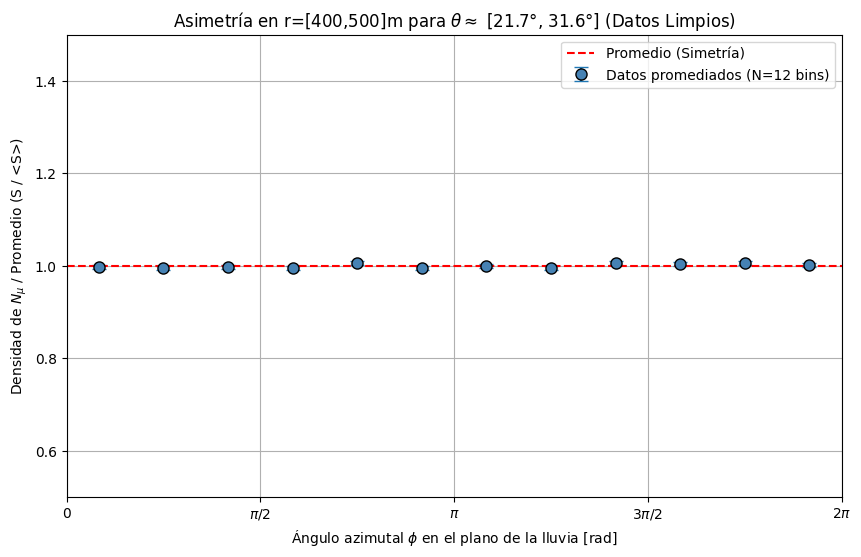

Procesando bin de theta 2: 148617 módulos encontrados.


/tmp/ipykernel_675626/2513961988.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


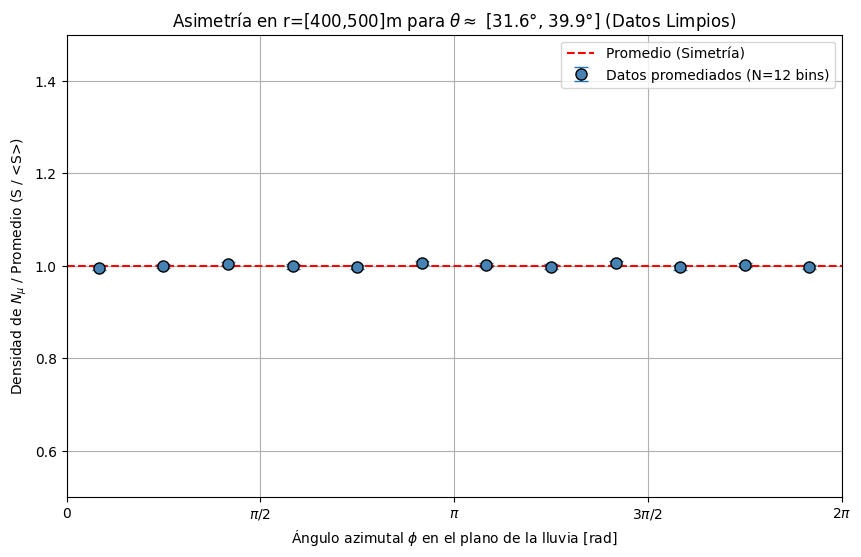

Procesando bin de theta 3: 142230 módulos encontrados.


/tmp/ipykernel_675626/2513961988.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


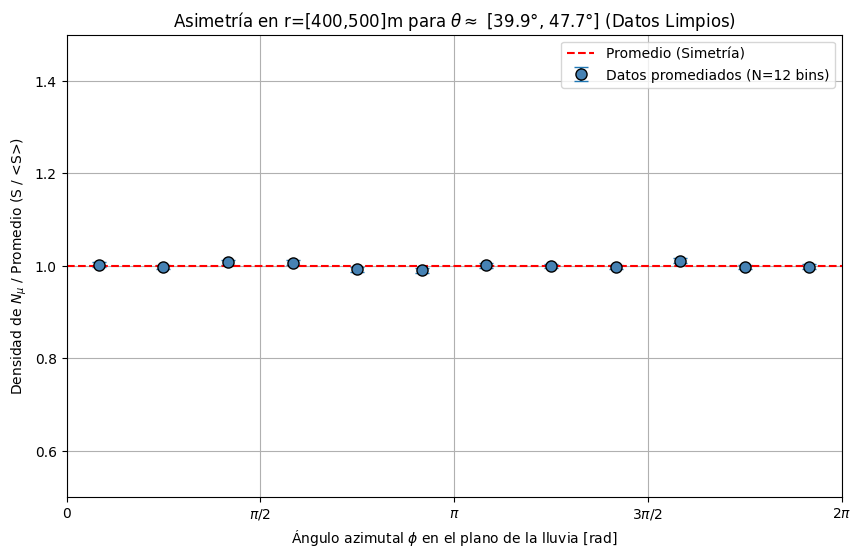

Procesando bin de theta 4: 128331 módulos encontrados.


/tmp/ipykernel_675626/2513961988.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


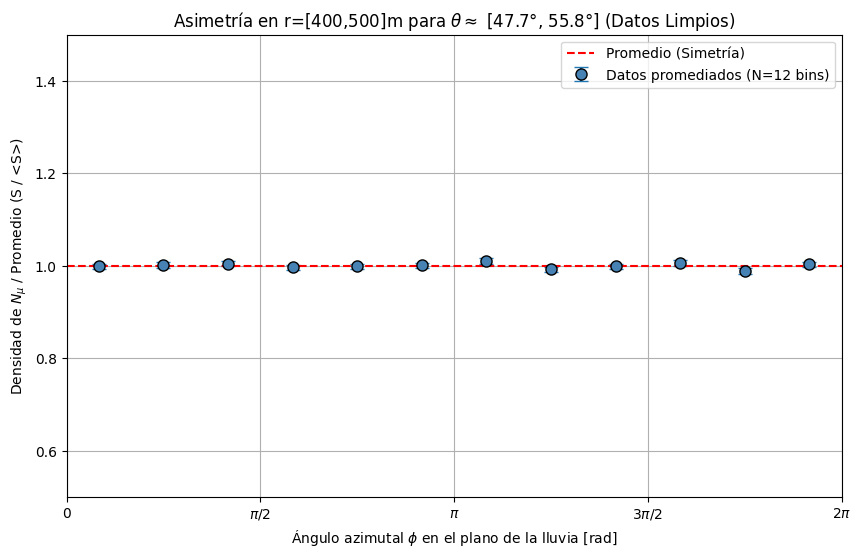

Procesando bin de theta 5: 68898 módulos encontrados.


/tmp/ipykernel_675626/2513961988.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(


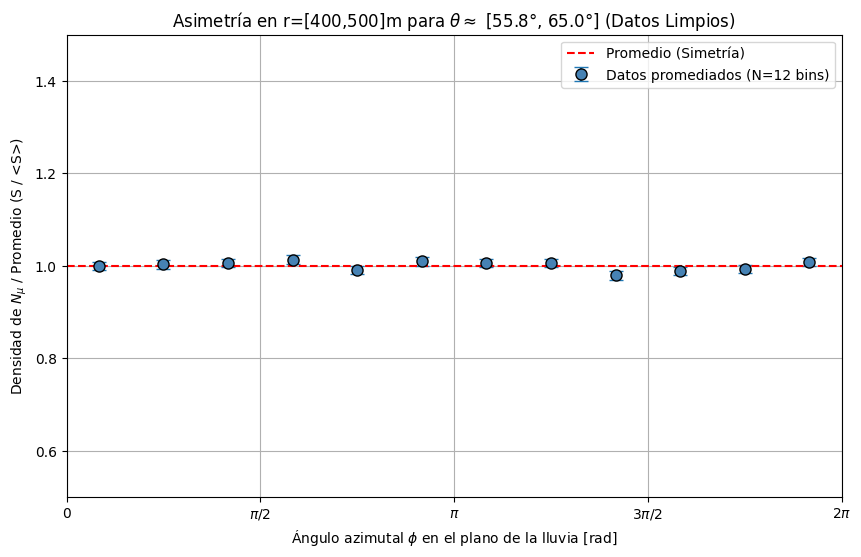

In [9]:
# --- 1. Parámetros (igual que los tuyos) ---
r_min = 400
r_max = 500
phi_plot_bins = 12

phi_bin_edges = np.linspace(0, 2 * np.pi, phi_plot_bins + 1)
phi_bin_labels = range(phi_plot_bins)
phi_bin_centers = (phi_bin_edges[:-1] + phi_bin_edges[1:]) / 2.0

# --- 2. Binning en Theta (igual que el tuyo) ---
N_theta_bins = 6
theta_min_deg = 0
theta_max_deg = 65 # (El código ya maneja el max real)

theta_max_real = df_new['theta_REC'].max()
theta_max_deg = min(theta_max_deg, theta_max_real) 
s2_min = np.sin(np.deg2rad(theta_min_deg))**2
s2_max = np.sin(np.deg2rad(theta_max_deg))**2
s2_bins = np.linspace(s2_min, s2_max, N_theta_bins + 1)
theta_bins_deg = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))

print(f"Bordes de bins en Theta (grados): {np.round(theta_bins_deg, 1)}")

if 's2_theta' not in df_new.columns:
    df_new['s2_theta'] = np.sin(np.deg2rad(df_new['theta_REC']))**2
    df_new['theta_bin'] = pd.cut(df_new['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)

# --- ❗️ 3. CREAMOS EL DF "LIMPIO" PRIMERO ❗️ ---
#    (¡Aquí aplicamos los cortes de calidad!)

# Como te dijeron, 'rejected' son los 90k, así que los queremos.
# Filtramos solo los 'silent' o 'undefined'.
status_buenos = ['candidate', 'rejected', 'saturated']

# Filtramos por status Y por el flag de saturación del SD
df_limpio = df_new[
    (df_new['module_status'].isin(status_buenos))].copy()
    
    
    
    #&
    #(df_new['is_sd_saturated'] == False)
#].copy()

print(f"Usando {len(df_limpio)} filas (módulos) 'limpios' (de {len(df_new)} totales)")


# --- 4. Bucle anidado (Ahora usa 'df_limpio') ---
print(f"\nAnalizando asimetría en el anillo r = [{r_min}, {r_max}] m")

for i in range(N_theta_bins):
    
    th_min_label = theta_bins_deg[i]
    th_max_label = theta_bins_deg[i+1]
    plot_title = f"Asimetría en r=[{r_min},{r_max}]m para $\\theta \\approx$ [{th_min_label:.1f}°, {th_max_label:.1f}°] (Datos Limpios)"

    # --- DOBLE FILTRO (Ahora sobre df_limpio) ---
    df_slice = df_limpio[
        (df_limpio['theta_bin'] == i) &
        (df_limpio['r_core'].between(r_min, r_max))
    ].copy()

    if df_slice.empty or len(df_slice) < 50:
        print(f"Datos insuficientes para el bin de theta {i}. Saltando.")
        continue
    
    print(f"Procesando bin de theta {i}: {len(df_slice)} módulos encontrados.")

    # --- CÁLCULO DE DENSIDAD (igual que tu código) ---
    df_slice['phi_bin'] = pd.cut(df_slice['phi_plane'], bins=phi_bin_edges, labels=phi_bin_labels, include_lowest=True)
    
    phi_stats = df_slice.groupby('phi_bin')['nMuones'].agg(
        mean_density='mean',
        std_dev='std',
        N_entries='count'
    )
    
    phi_stats['sem'] = phi_stats['std_dev'] / np.sqrt(phi_stats['N_entries'])
    
    # --- Normalizar (S/<S>) ---
    overall_mean_density = phi_stats['mean_density'].mean()
    phi_stats['S_norm'] = phi_stats['mean_density'] / overall_mean_density
    phi_stats['S_norm_err'] = phi_stats['sem'] / overall_mean_density
    
    phi_stats['phi_center'] = phi_bin_centers[phi_stats.index.astype(int)]

    # --- Plotear con Barras de Error ---
    plt.figure(figsize=(10, 6))
    
    plt.errorbar(
        phi_stats['phi_center'],
        phi_stats['S_norm'],
        yerr=phi_stats['S_norm_err'],
        fmt='o', ms=8, mec='black', mfc='steelblue', capsize=5,
        label=f'Datos promediados (N={phi_plot_bins} bins)'
    )

    plt.xlabel(r"Ángulo azimutal $\phi$ en el plano de la lluvia [rad]")
    plt.ylabel(r"Densidad de $N_{\mu}$ / Promedio (S / <S>)")
    plt.title(plot_title)
    plt.xticks(np.linspace(0, 2*np.pi, 5), ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
    plt.xlim(0, 2 * np.pi)
    plt.ylim(0.5, 1.5)
    plt.axhline(1.0, color='r', linestyle='--', label='Promedio (Simetría)')
    plt.grid(True)
    plt.legend()
    plt.show()

# Lo mismo pero ahora usando tambien el SD

Bordes de bins en Theta (grados): [ 0.  21.7 31.6 39.9 47.7 55.8 65. ]

Analizando asimetría en el anillo r = [430, 470] m
Procesando bin de theta 0: 1033 counters encontrados.


/tmp/ipykernel_283174/3420545469.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin').agg(


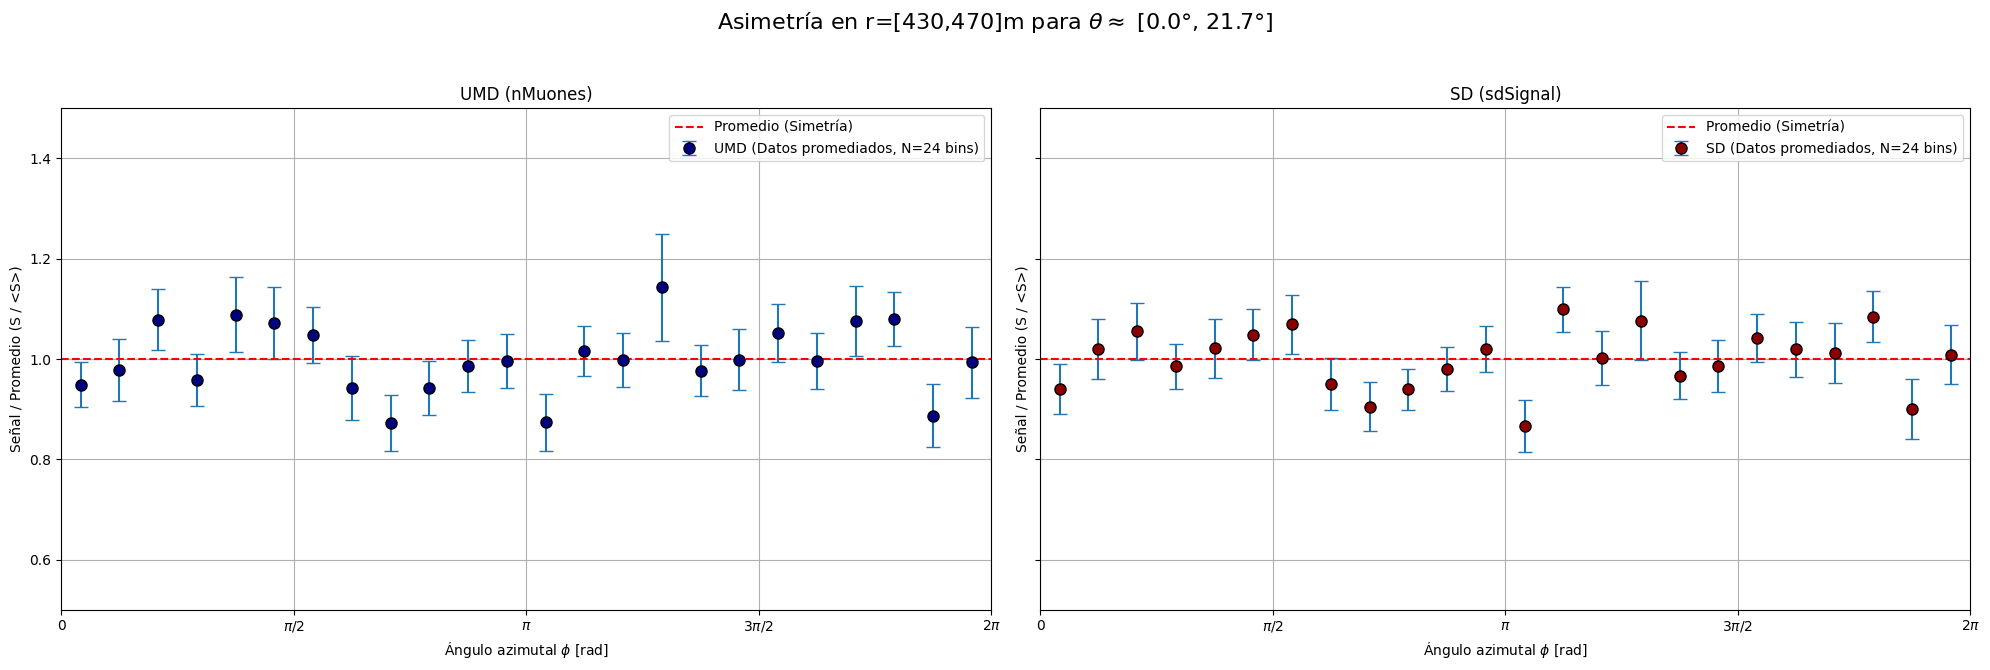

Procesando bin de theta 1: 995 counters encontrados.


/tmp/ipykernel_283174/3420545469.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin').agg(


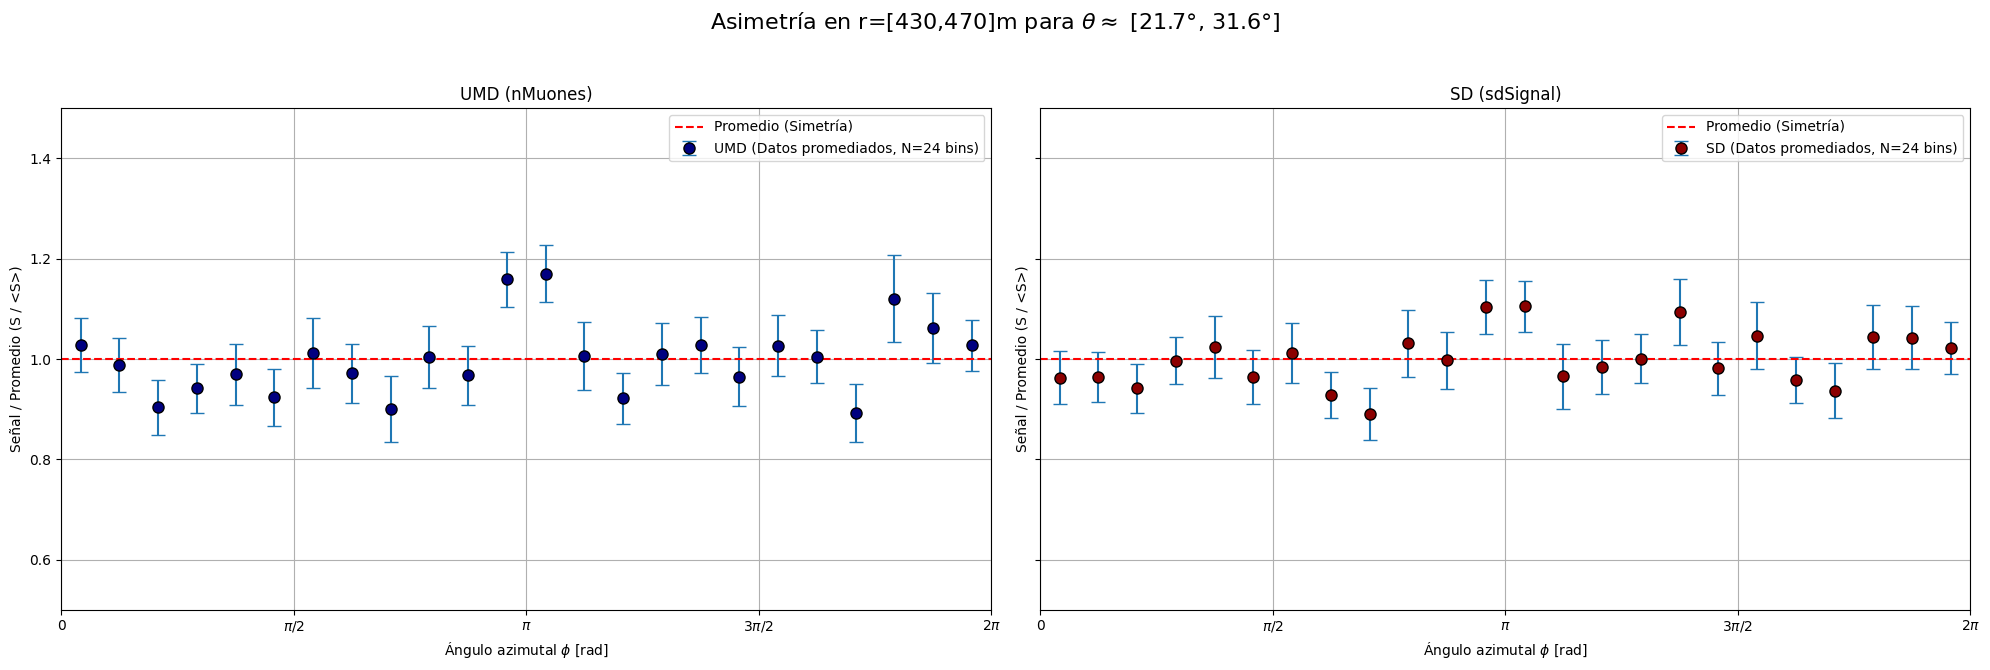

Procesando bin de theta 2: 1120 counters encontrados.


/tmp/ipykernel_283174/3420545469.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin').agg(


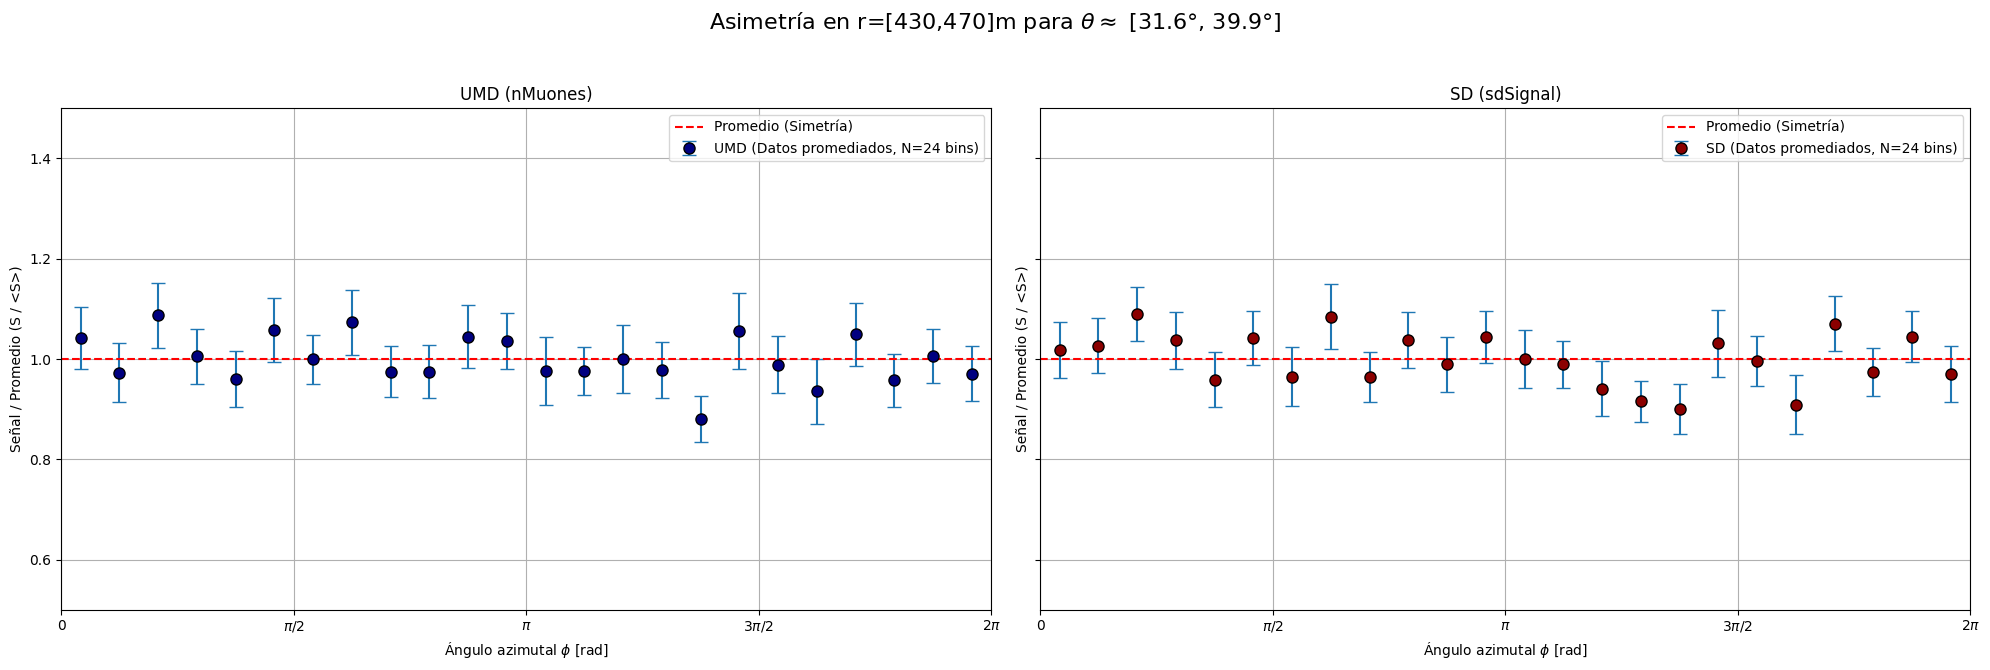

Procesando bin de theta 3: 1329 counters encontrados.


/tmp/ipykernel_283174/3420545469.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin').agg(


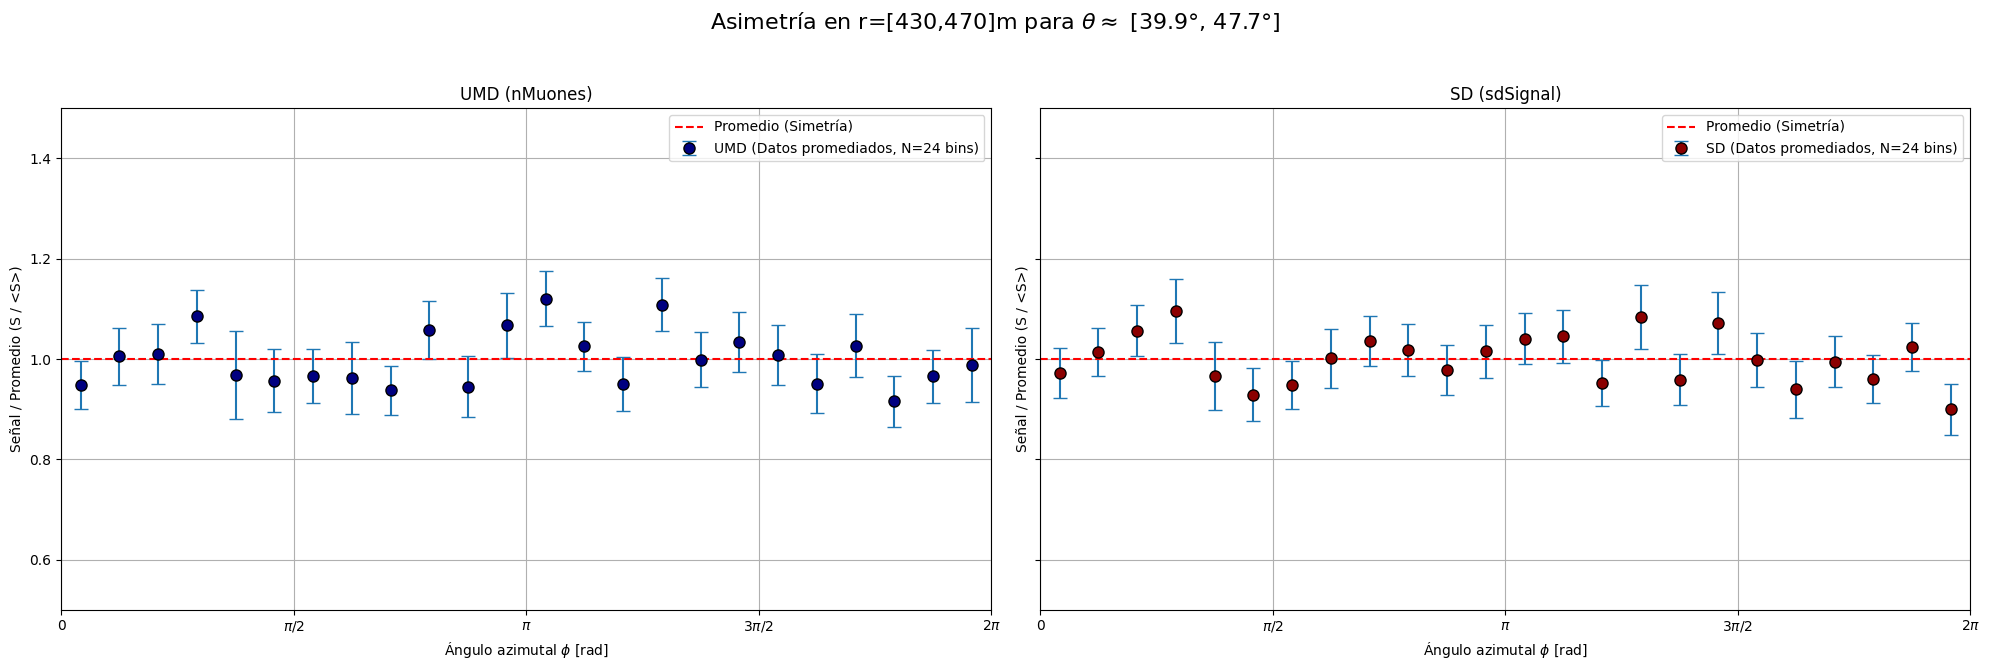

Procesando bin de theta 4: 1593 counters encontrados.


/tmp/ipykernel_283174/3420545469.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin').agg(


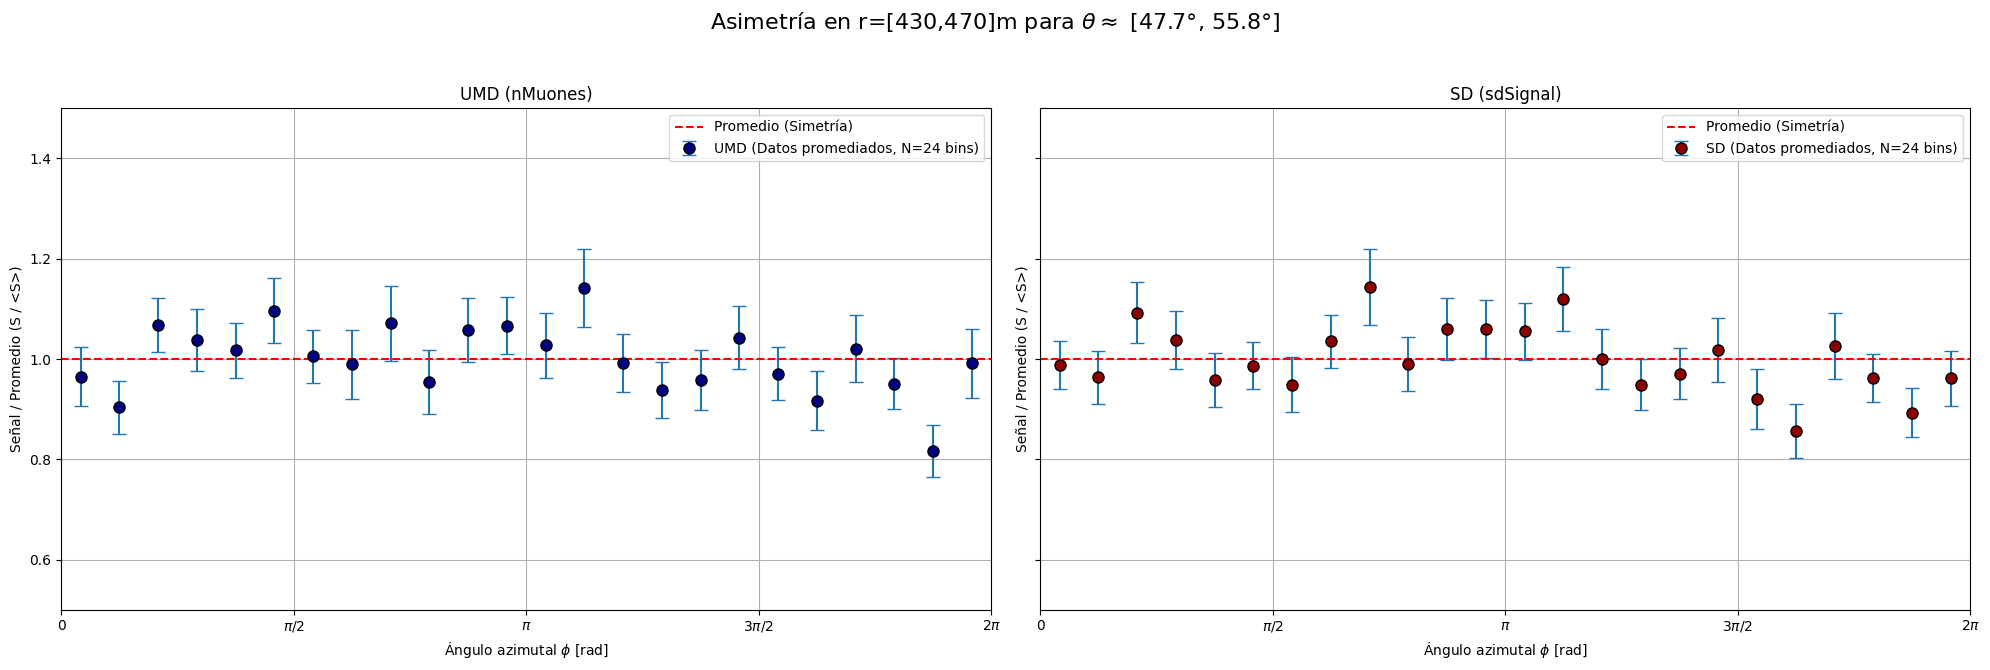

Procesando bin de theta 5: 1178 counters encontrados.


/tmp/ipykernel_283174/3420545469.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phi_stats = df_slice.groupby('phi_bin').agg(


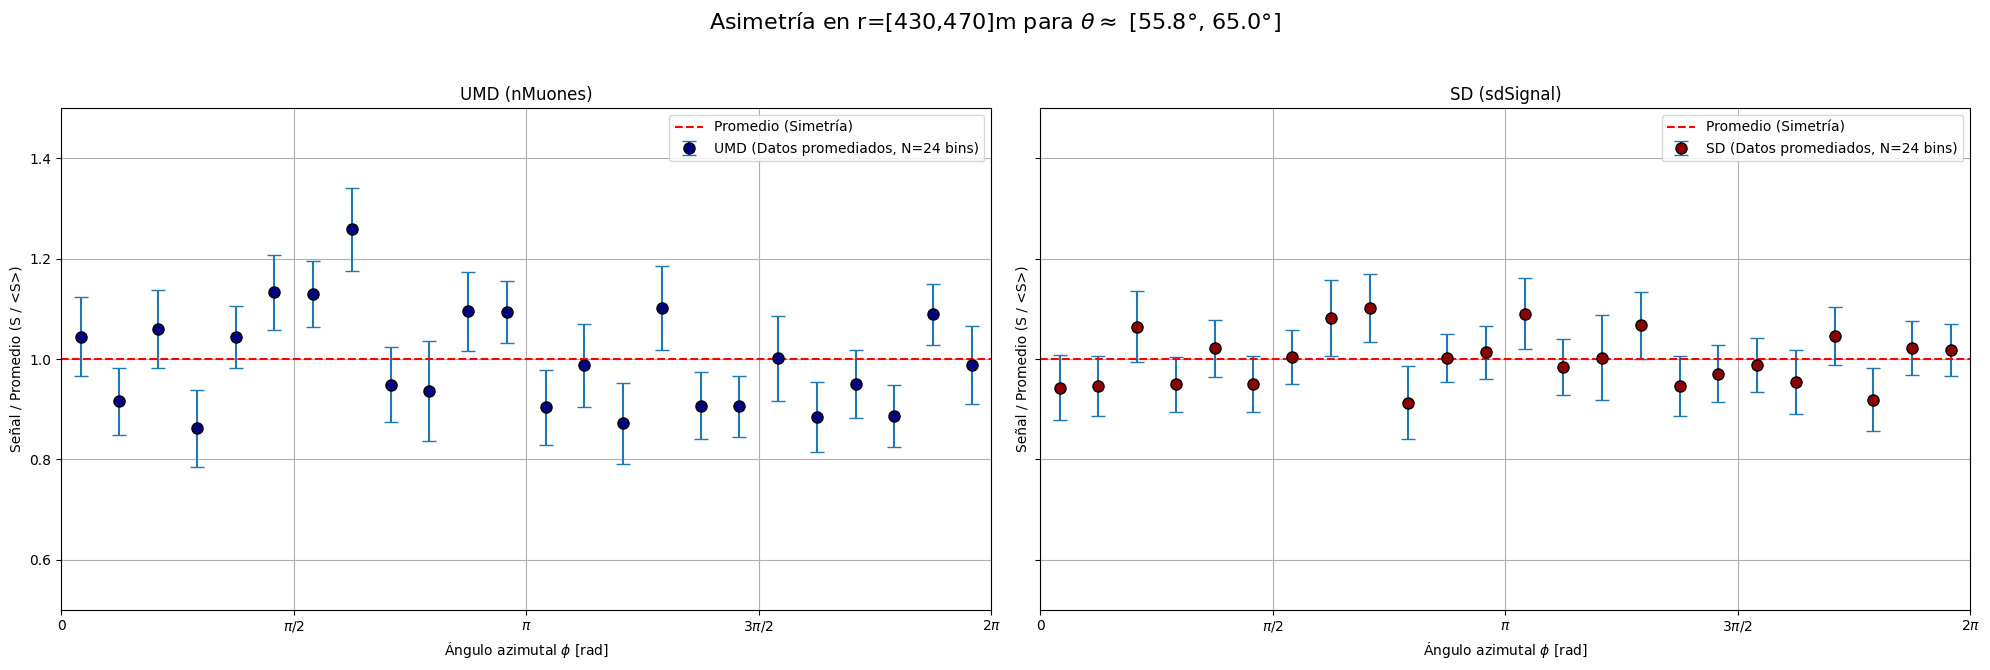

In [10]:
# --- 1. Parámetros de binning (r y phi) ---
r_min = 430
r_max = 470
phi_plot_bins = 24 # 24 bins es un buen número

phi_bin_edges = np.linspace(0, 2 * np.pi, phi_plot_bins + 1)
# ❗️ CAMBIO: Creamos "labels" para los bins (índices 0, 1, 2, ...)
phi_bin_labels = range(phi_plot_bins)
# Centros de los bins (sigue igual)
phi_bin_centers = (phi_bin_edges[:-1] + phi_bin_edges[1:]) / 2.0

# --- 2. Parámetros de binning en sin^2(theta) ---
N_theta_bins = 6
theta_min_deg = 0
theta_max_deg = 65

theta_max_real = df_new['theta_REC'].max()
theta_max_deg = min(theta_max_deg, theta_max_real) 

s2_min = np.sin(np.deg2rad(theta_min_deg))**2
s2_max = np.sin(np.deg2rad(theta_max_deg))**2
s2_bins = np.linspace(s2_min, s2_max, N_theta_bins + 1)
theta_bins_deg = np.rad2deg(np.arcsin(np.sqrt(s2_bins)))

print(f"Bordes de bins en Theta (grados): {np.round(theta_bins_deg, 1)}")

# Asignamos cada FILA (counter) a un bin de theta (sigue igual)
if 's2_theta' not in df_new.columns:
    df_new['s2_theta'] = np.sin(np.deg2rad(df_new['theta_REC']))**2
    df_new['theta_bin'] = pd.cut(df_new['s2_theta'], bins=s2_bins, labels=False, include_lowest=True)

# --- 3. Bucle anidado (sigue igual) ---
print(f"\nAnalizando asimetría en el anillo r = [{r_min}, {r_max}] m")

for i in range(N_theta_bins):
    
    th_min_label = theta_bins_deg[i]
    th_max_label = theta_bins_deg[i+1]
    plot_title_prefix = f"Asimetría en r=[{r_min},{r_max}]m para $\\theta \\approx$ [{th_min_label:.1f}°, {th_max_label:.1f}°]"

    # --- DOBLE FILTRO (sigue igual) ---
    df_slice = df_new[
        (df_new['theta_bin'] == i) &
        (df_new['r_core'].between(r_min, r_max)) &
        (df_new['sdSignal'].notna()) &
        (df_new['nMuones'].notna())
    ].copy()

    if df_slice.empty or len(df_slice) < 50:
        print(f"Datos insuficientes para el bin de theta {i}. Saltando.")
        continue
    
    print(f"Procesando bin de theta {i}: {len(df_slice)} counters encontrados.")

    # --- ❗️ CÁLCULO DE DENSIDAD (MÉTODO LEGIBLE CON GROUPBY) ---
    
    # 1. Asignamos cada counter a su bin de phi
    df_slice['phi_bin'] = pd.cut(df_slice['phi_plane'], bins=phi_bin_edges, labels=phi_bin_labels, include_lowest=True)
    
    # 2. Calculamos media, std y N (count) para AMBAS señales en un solo paso
    phi_stats = df_slice.groupby('phi_bin').agg(
        # Stats para UMD (nMuones)
        umd_mean_density=('nMuones', 'mean'),
        umd_std_dev=('nMuones', 'std'),
        umd_N_entries=('nMuones', 'count'),
        
        # Stats para SD (sdSignal)
        sd_mean_density=('sdSignal', 'mean'),
        sd_std_dev=('sdSignal', 'std'),
        sd_N_entries=('sdSignal', 'count') # sd_N será igual a umd_N
    )
    
    # 3. Calculamos el Error Estándar de la Media (SEM) para ambos
    phi_stats['umd_sem'] = phi_stats['umd_std_dev'] / np.sqrt(phi_stats['umd_N_entries'])
    phi_stats['sd_sem'] = phi_stats['sd_std_dev'] / np.sqrt(phi_stats['sd_N_entries'])

    # --- 4. Normalizar (S/<S>) para ambos ---
    umd_overall_mean = phi_stats['umd_mean_density'].mean()
    sd_overall_mean = phi_stats['sd_mean_density'].mean()

    phi_stats['umd_S_norm'] = phi_stats['umd_mean_density'] / umd_overall_mean
    phi_stats['umd_S_norm_err'] = phi_stats['umd_sem'] / umd_overall_mean # Error propagado
    
    phi_stats['sd_S_norm'] = phi_stats['sd_mean_density'] / sd_overall_mean
    phi_stats['sd_S_norm_err'] = phi_stats['sd_sem'] / sd_overall_mean # Error propagado
    
    # Agregamos los centros de los bins para el plot
    # (usamos .loc para asegurarnos de alinear con el índice 0-23)
    phi_stats['phi_center'] = phi_stats.index.map(lambda x: phi_bin_centers[x])

    # --- 5. Plotear (ahora el loop es más simple) ---
    fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
    fig.suptitle(plot_title_prefix, fontsize=16)

    # --- Plot 1: UMD (nMuones) ---
    axs[0].errorbar(
        phi_stats['phi_center'],
        phi_stats['umd_S_norm'],
        yerr=phi_stats['umd_S_norm_err'], # <-- Barras de error
        fmt='o', ms=8, mec='black', mfc='navy', capsize=5,
        label=f'UMD (Datos promediados, N={phi_plot_bins} bins)'
    )
    axs[0].set_title('UMD (nMuones)')

    # --- Plot 2: SD (sdSignal) ---
    axs[1].errorbar(
        phi_stats['phi_center'],
        phi_stats['sd_S_norm'],
        yerr=phi_stats['sd_S_norm_err'], # <-- Barras de error
        fmt='o', ms=8, mec='black', mfc='darkred', capsize=5,
        label=f'SD (Datos promediados, N={phi_plot_bins} bins)'
    )
    axs[1].set_title('SD (sdSignal)')

    # --- Styling (aplicado a ambos) ---
    for ax in axs:
        ax.set_xlabel(r"Ángulo azimutal $\phi$ [rad]")
        ax.set_ylabel(r"Señal / Promedio (S / <S>)")
        ax.set_xticks(np.linspace(0, 2*np.pi, 5), ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
        ax.set_xlim(0, 2 * np.pi)
        ax.set_ylim(0.5, 1.5)
        ax.axhline(1.0, color='r', linestyle='--', label='Promedio (Simetría)')
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [12]:
print(df_new['sdId'].unique())

[4022 4023 4041 4021 4009 4010 4040 4216 4055 4215 4033 4032 4054 4056
 4075 4218 4214 4074 4003 4002 4001 4004 4011 4008 4019 4007 4018 4012
 4005 4025 4026 4045 4027 4047 4044 4013 4067 4031 4016 4015 4030 4029
 4052 4017 4024 4043 4014 4028 4049 4053 4212 4213 4073 4217 4048 4051
 4006 4034 4035 4058 4057 4046 4039 4020 4036 4038 4037 4061 4060 4042
 4059 4163 4064 4050 4096 4066 4097 4072 4188 4158 4151 4095 4116 4069
 4063 4130 4078 4081 4125 4071 4193 4106 4079 4206 4132 4085 4129 4070
 4076 4112 4062 4162 4068 4080 4086 4107 4077 4094 4083 4093 4127 4121
 4090 4198 4113 4115 4149 4084 4065 4099 4156 4117 4088 4155 4183 4101
 4143 4082 4187 4087 4157 4102 4167 4092 4150 4119 4120 4111 4169 4182
 4100 4160 4174 4203 4103 4098 4108 4154 4138 4147 4126 4091 4122 4128
 4142 4133 4089 4123 4204 4137 4199 4161 4202 4175 4159 4148 4207 4164
 4166 4131 4179 4145 4196 4141 4189 4136 4165 4192]
